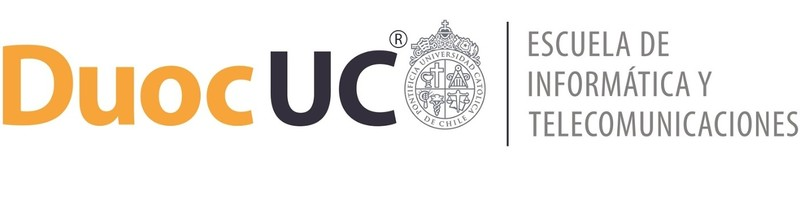

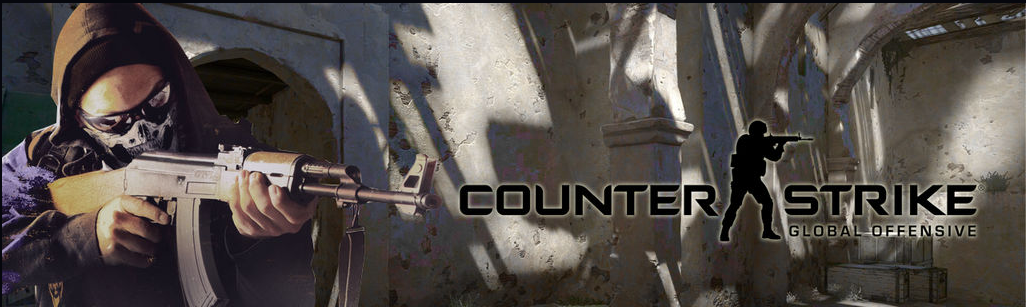

# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Paula Frías Navarro
* Sebastián Valdivia Estay

Docente: Manuel Tello Ortega

Sección: MLY0100 - 001D

# Caso Fundamentos de Machine Learning

CONTEXTO CASO

Valve, los ha contactado como equipo de análisis de datos y modelado de Machine Learning para analizar y realizar modelos predictivos sobre los datos.

En cada partida de Counter Strike: GO dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan.


El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Los datos a utilizar corresponden a sobre 7000 partidas del juego (con un máximo de 10 jugadores c/u)  


Los datos han sido extraídos de replays, los cuales son archivos propietarios con la información de cada una de las acciones realizadas por cada jugador dentro de una partida. Los replays han sido extraídos de la red utilizando un scrapper y pre-procesados utilizando un script.  



En este caso, la data corresponde a un archivo CSV con 79.157 filas, cada una correspondiente a un jugador dentro de una partida. El archivo contiene 29 columnas correspondientes a variables que describen las acciones del jugador dentro del juego.


$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline Map & \text {Nombre  del Mapa donde se jugó la partida}  \\
\hline \text{ Team} & \text { Nombre de equipo al que pertenece el jugador} \\
\hline \text{ InternalTeamId} & \text { Identificador del equipo al que pertenece el jugador.} \\
\hline \text{ MatchId} & \text { Identificador de la partida.} \\
\hline \text{ RoundId} & \text { Identificador de la ronda (los equipos se enfrentan en rondas de 5 partidas seguidas)} \\
\hline \text{ MatchWinner} & \text { Indica si el jugador ganó o no la partida.} \\
\hline \text{ RoundWinner} & \text { Indica si el jugador ganó o no la ronda analizada.} \\
\hline \text{ Survived} & \text { Indica si el jugador sobrevivió o no a la partida (sobrevivir no es sinónimo de ganar).} \\
\hline \text{ AbnormalMatch} & \text { Indica si la partida del jugador tuvo un error por conexión de red} \\
\hline \text{ TimeAlive} & \text { Indica el tiempo en segundos que el jugador estuvo vivo durante el juego} \\
\hline \text{ TravelledDistance} & \text { Distancia viajada por el jugador durante la partida.} \\
\hline \text{ RLethalGrenadesThrown/RNonLethalGrenadesThrown} & \text { Cantidad de granadas lanzadas, categorizadas en letales y no-letales.} \\
\hline \text{ PrimaryXXXX} & \text { Porcentaje de uso arma clasificada como primaria. Categorizada en AssaultRifle, SniperRifle, SMG, Heavy y Pistol.} \\
\hline \text{ [Match|Round] Assists} & \text { Cantidad de asistencias efectuadas por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] Kills} & \text { Cantidad de kills efectuados por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] FlankKills} & \text { Cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.} \\
\hline \text{ [Match|Round] HeadShots} & \text { Cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.} \\
\hline \text{ RoundStartingEquipmentValue} & \text { Valor del equipamiento llevado por el jugador al inicio de la ronda.} \\
\hline \text{ TeamStartingEquipmentValue} & \text { Valor promedio del equipamiento llevado por el equipo del jugador al inicio de la ronda.} \\
\end{array}
\end{aligned}
$$

## Fase 1: Business Understanding

### 1.1. Contexto del caso de estudio
Counter-Strike: Global Offensive (CS:GO), es un videojuego de disparos en primera persona (First-Person Shooter), este es una mejora de las versiones anteriores de la saga de Counter-Strike. CS:GO, cuenta con ajustes en equilibrio de armas, mecánicas de disparo, sistema económico y una interfaz modernizada. Además, incluye un sistema de emparejamiento basado en clasificación denominado ELO, que permite emparejar a jugadores de un nivel similar.  
Cuenta con diversos modos de juego, siendo los más populares el modo casual y el modo competitivo. En particular, el modo competitivo de plantar y desactivar la bomba es el más representativo dentro de la escena de los e-sports.  
En este modo, los jugadores se dividen en dos equipos: Terroristas (T) y Antiterroristas (CT). El objetivo del equipo Terrorista es plantar una bomba (C4) en una zona designada del mapa, mientras que el equipo Antiterrorista debe evitar la plantación o desactivar la bomba antes que esta detone.  
### 1.2. Desarrollo de una partida
Una partida competitiva consiste en desactivar/plantar la bomba, y se desarrolla entre equipos de 5vs5, donde encontramos dos bandos: Terroristas (T) y Antiterroristas (CT). El enfrentamiento se compone en diversas rondas consecutivas donde el objetivo principal es ganar la mayor cantidad de rondas posibles, cada una de estas cuenta son su toma de desiciones independiente. El equipo que alcanza 16 rondas ganadas obtiene la victoria. No es necesario jugar todas las rondas disponibles, ya que la partida finaliza una vez que uno de los equipos logra una ventaja suficiente.

Sobre la duración de cada ronda el tiempo es total es de 1:55, durante este tiempo, los jugadores deben ejecutar estrategias ofensivas o defensivas dependiendo de su bando. En el caso de los Terroristas, el objetivo es plantar el explosivo C4, mientras que los Antiterroristas deben eliminar a los terroristas o desactivar la bomba si esta fue plantada.

Las condiciones de victoria varian segun el desarrollo de las rondas, entre estas se incluyen:
- Eliminar al equipo rival (Por parte de los Terroristas)
- Cumplimiento de los objetivos (Detonación de bomba para Terroristas. Desactivación por parte de Antiterroristas)
- Finalización del tiempo sin que se haya plantado (Solo para los Antiterroristas)

Al inicio de cada ronda, los jugadores reciben recompensas económicas basadas en su desempeño individual y grupal, con un límite máximo de $16.000 por jugador. El sistema otorga bonos por ganar rondas, conseguir bajas, plantar o desactivar el C4, además de un bono por rondas perdidas consecutivas para equilibrar la partida, pero esto no solo los premia si no que tambien le permite al sistema construir métricas de desempeño individual y analizarlo con el resultado.

Para finalizar la tienda contiene los siguientes elementos a disposición de la economía del jugador y del equipo, para planear su estrategia:
- Armamento se divide en: Rifles (Fusil. AssaultRifle, SniperRifle), Metralletas (Subfusil, SMG), Armamento pesado (Heavy) y Pistola (Pistol).
- Equipo de utilidad incluye: Chaleco, Chaleco antibalas + casco, Zeus (Taser) y el kit de defuse.
- Granadas, que permiten llevar hasta cuatro unidades, incluyendo: Granadas incendiarias (Exclusiva Antiterroristas) o Molotov (Exclusiva Terroristas), Señuelo (Decoy), Aturdidora (FlashBang), Alto explosivo (HE) y de Humo (Smoke).
### 1.3. Desempeño de los jugadores y estilos de juego
El rendimiento de un jugador no se mide únicamente por la cantidad de eliminaciones realizadas, sino por su impacto general dentro de la ronda y su aporte al éxito del equipo. En la escena competitiva, existen diversas métricas utilizadas para evaluar el desempeño, como el Rating de HLTV, el ADR (Average Damage per Round) y el KAST (Kill, Assist, Survive, Trade), las cuales consideran factores como daño causado, supervivencia y participación en jugadas clave.

Sin embargo, estas métricas avanzadas no siempre se encuentran disponibles durante el juego a simple vista por lo mismo el desempeño puede ser analizado a través de variables como:

- Cantidad de eliminaciones (kills): Refleja la capacidad ofensiva del jugador durante la ronda.
- Asistencias: Indican participación indirecta en eliminaciones.
- Tiempo de vida (`TimeAlive`): Permite analizar la supervivencia y permanencia en la ronda.
- Distancia recorrida (`TravelledDistance`): Puede asociarse al nivel de actividad o movilidad del jugador.
- Uso de granadas: Representa decisiones tácticas que pueden influir en el desarrollo de la ronda.

Todas estas variables permiten construir un análisis del impacto del jugador dentro del juego.

Por otro lado, el comportamiento de los jugadores dentro de la partida también está definido por distintos estilos de juego. Algunos de los más populares incluyen:

- Holding: Mantener una posición defensiva esperando al enemigo.
- Lurking: Moverse de forma independiente para sorprender al rival.
- Rush: Ejecutar ataques rápidos y coordinados hacia un objetivo.
- Trading: Eliminar a un enemigo inmediatamente después de que este haya eliminado a un compañero.

Estos estilos de juego se pueden inferirse indirectamente a partir de variables como el movimiento, las eliminaciones y el uso de recursos.

En este contexto, el rendimiento de un jugador puede entenderse como una combinación de factores individuales y estratégicos, lo que permite analizar cómo distintas variables contribuyen al resultado de la ronda o de la partida.
A partir de los elementos descritos anteriormente, es posible observar que se presenta un entorno altamente estructurado donde cada ronda puede ser analizada como una unidad independiente de información. En cada una de estas rondas intervienen múltiples factores, tales como el equipamiento inicial, las decisiones tácticas, el desempeño individual de los jugadores y el contexto del mapa y del bando.

Si bien muchos de estos elementos corresponden a comportamientos complejos dentro del juego, una parte importante de ellos puede ser representada mediante variables cuantificables presentes en el dataset, como la cantidad de eliminaciones (`[Match|Round] Assists`/`Kills`/`FlankKills`/`HeadShots`), el uso de granadas (`RLethalGrenadesThrown`/`RNonLethalGrenadesThrown`), el tiempo de supervivencia (`TimeAlive`), la distancia recorrida (`TravelledDistance`) y el valor del equipamiento (`RoundStartingEquipmentValue`, `TeamStartingEquipmentValue`). Esto permite transformar un entorno dinámico y estratégico en información estructurada susceptible de análisis.

Desde esta perspectiva, el caso de estudio resulta especialmente adecuado para la aplicación de técnicas de análisis de datos y Machine Learning, ya que permite explorar relaciones entre variables, identificar patrones de comportamiento y evaluar qué factores tienen mayor influencia en el resultado de una partida, la predicción del equipo ganador de una ronda o la estimación del desempeño individual de un jugador.
### 1.4. Objetivo general
Se definió que el análisis de uso de armamento y granadas es capaz de predecir la victoria en una ronda de CS:GO competitivo, considerando el mapa y el bando del jugador. Por lo anterior se consideraron relevantes los siguientes aspectos:

- La relación entre el tipo de armamento utilizado y el resultado de la ronda.
- Impacto del uso de granadas en la probabilidad de victoria.
- Cómo el mapa influye en la efectividad del equipamiento.
- Diferencias entre el bando Terrorista y Antiterrorista.


### 1.5. Hipótesis
Se definió más de una hipótesis:

Hipótesis principal: El uso de armamento y granadas influye significativamente en la probabilidad de ganar una ronda, y su efecto varía según el mapa y el bando.

Hipótesis secundaria 1: Un mayor uso de granadas está asociado a una mayor probabilidad de victoria.

Hipótesis secundaria 2: El tipo de armamento tiene distinta efectividad dependiendo del mapa.


## Fase 2: Data Understanding
Como segundo paso después de hacer el estudio de mercado, se realizó un análisis explorativo de las variables y datos, de esta forma se logró entender el contenido, las variables más relevantes, su relación entre ellas y poder visualizar ciertos patrones.
### 2.1. Importar librerías y hacer la carga del dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


In [2]:
# Definimos las rutas
file_name = 'demo_round_traces_fixed.csv'
drive_path = f'/content/drive/MyDrive/Trabajo Machine Learning/{file_name}'
local_path = file_name  # Misma carpeta de ejecución

try:
    from google.colab import drive
    # 1. Intentamos montar Drive y leer el archivo
    drive.mount('/content/drive', timeout_ms=10000) # Timeout opcional
    df = pd.read_csv(drive_path, sep=";")
    print("Archivo cargado desde Google Drive")

except Exception:
    try:
        # 2. Intento de carga local (si lo anterior falla)
        df = pd.read_csv(local_path, sep=";")
        print("Archivo cargado desde el almacenamiento local")
    except Exception:
        print(f"El archivo '{file_name}' no se encuentra en Drive ni en Local.")

Archivo cargado desde el almacenamiento local


### 2.2. Visión General de los Datos

In [3]:
df.shape

(79157, 29)

La funcion `.shape()` entregó la cantidad totales de columnas y filas. Columnas: 29 y Filas: 79.157

In [4]:
# Revisamos los primeros 5 registros
df.head(5)

,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,de_inferno,Terrorist,1,4,1,False,True,False,False,51.120249,...,0,0,0,0,750,4400,0,0,0,0
1,de_inferno,Terrorist,1,4,1,False,True,False,False,43.486626,...,0,0,0,0,800,4400,0,0,0,0
2,de_inferno,Terrorist,1,4,1,False,True,False,False,37.354698,...,0,0,0,0,1000,4400,0,0,0,0
3,de_inferno,Terrorist,1,4,1,False,True,False,False,47.678861,...,0,0,0,0,850,4400,0,0,0,0
4,de_inferno,Terrorist,1,4,1,False,True,True,False,53.122511,...,0,0,0,0,1000,4400,0,0,0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79157 entries, 0 to 79156
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Map                          79157 non-null  object 
 1   Team                         79157 non-null  object 
 2   InternalTeamId               79157 non-null  int64  
 3   MatchId                      79157 non-null  int64  
 4   RoundId                      79157 non-null  int64  
 5   RoundWinner                  79157 non-null  bool   
 6   MatchWinner                  79157 non-null  bool   
 7   Survived                     79157 non-null  bool   
 8   AbnormalMatch                79157 non-null  bool   
 9   TimeAlive                    79157 non-null  float64
 10  TravelledDistance            79157 non-null  float64
 11  RLethalGrenadesThrown        79157 non-null  int64  
 12  RNonLethalGrenadesThrown     79157 non-null  int64  
 13  PrimaryAssaultRi

La funcion `.info()`, entregó un resumen del dataframe. Especifica el tipo de dato de cada columna. Además, de entregar un recuento de cantidad de columnas segun su tipo de dato, dtypes: bool(4), float64(7), int64(16), object(2).

Filas totales: 79157 Columnas totales: 29

### 2.3. Clasificación de Datos de las Columnas
1. Variables de Identificación y Contexto (Categóricas Nominales)
Estas variables cumplen la función de agrupar los datos y comprender el entorno de las partidas.
- `Map`: Describe el escenario donde se desarrolló el combate. Es una variable categórica nominal. Es de alta relevancia esto se debe a que ciertas armas y estrategias son más efectivas dependiendo del mapa (por ejemplo, mapas de larga o corta distancia).
- `Team`: Indica el bando del jugador (Terrorist o Counter-Terrorist). Es categórica nominal. Fundamental para el análisis, ya que cada bando tiene objetivos, equipamiento y utilidades (granadas) exclusivas.
- `InternalTeamId` / `MatchId`: Identificadores únicos para equipos y partidas. Son categóricas nominales (aunque se representen con números, funcionan como etiquetas).
- `RoundId`: Indica el número de ronda dentro de la partida. Es numérica discreta. Permite analizar la progresión de la partida y el impacto de las rachas de victorias o derrotas.
2. Variables de Desempeño del Jugador (Numéricas Discretas)
Estas métricas reflejan la capacidad ofensiva y el impacto individual en la ronda y el partido.
- `RoundKills` / `MatchKills`: Cantidad de eliminaciones. Son numéricas discretas. Son indicadores clave del rendimiento.
- `RoundAssists` / `MatchAssists`: Participación indirecta en eliminaciones. Numérica discreta.
- `RoundHeadshots` / `MatchHeadshots`: Eliminaciones mediante disparos a la cabeza. Numérica discreta. Refleja la precisión técnica del jugador.
- `RoundFlankKills` / `MatchFlankKills`: Eliminaciones efectuadas sin que el jugador sea detectado por el enemigo. Numérica discreta. Está estrechamente ligada a tácticas de lurking (movimiento sigiloso para flanquear).
3. Variables de Equipamiento y Economía (Numéricas)  
Relacionadas a la gestión de recursos por parte del equipo y jugador.
- `RoundStartingEquipmentValue`: Valor monetario del equipo al iniciar la ronda. Numérica continua. Es un indicador de la estrategia económica: valores bajos sugieren una eco-round (ahorro) y valores altos una ronda de compra completa (full buy).
- `TeamStartingEquipmentValue`: Valor promedio del equipo de todo el grupo. Numérica continua. Permite evaluar la ventaja o desventaja económica global del equipo frente al oponente.
- `PrimaryAssaultRifle` / `SniperRifle` / `Heavy` / `SMG` / `Pistol`: Representan el porcentaje de uso de cada tipo de armamento primario. Son variables numéricas continuas. Estos datos permiten definir el "perfil armamentístico" y su efectividad según el entorno.
- `RLethalGrenadesThrown` / `RNonLethalGrenadesThrown`: Cantidad de granadas lanzadas (daño vs. utilidad). Numéricas discretas. Ayudan a medir el impacto del uso de utilidad en la victoria de una ronda.
4. Variables de Tiempo y Movimiento (Numéricas Continuas)
- `TimeAlive`: Tiempo de supervivencia en segundos durante la ronda. Numérica continua. Es vital para calcular métricas de impacto como el KAST (supervivencia).
- `TravelledDistance`: Distancia total recorrida. Numérica continua. Se asocia al nivel de actividad, movilidad y roles tácticos como el rotate (movimiento entre sitios de bomba).
- `FirstKillTime`:A pesar de que la variable no se definió al comienzo del informe, por el nombre se asume a que es el tiempo en el que se realizó la primera baja de la ronda. Numérica continua.
5. Variables de Resultado y Estado (Categóricas Nominales / Booleanas)
- `RoundWinner` (Target propuesto): Indica si el equipo ganó la ronda. Es categórica nominal (booleana).
- `MatchWinner`: Indica si el equipo ganó la partida. Categórica nominal (booleana).
- `Survived`: Indica si el jugador terminó la ronda con vida. Categórica nominal (booleana).
- `AbnormalMatch`: Indica si la partida tuvo irregularidades. Categórica nominal (booleana).



In [6]:
df.describe()

,InternalTeamId,MatchId,RoundId,TimeAlive,TravelledDistance,RLethalGrenadesThrown,RNonLethalGrenadesThrown,PrimaryAssaultRifle,PrimarySniperRifle,PrimaryHeavy,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
count,79157.000000,79157.000000,79157.000000,79157.000000,7.915700e+04,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,...,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000
mean,1.500006,250.525033,12.765517,72.795720,1.041888e+05,0.498667,1.258057,0.675363,0.089840,0.005964,...,0.671349,0.146178,0.301553,0.095633,3778.108695,18890.133532,8.511578,1.209912,1.874831,3.858484
std,0.500003,149.557804,7.432837,48.321035,3.543487e+05,0.597985,1.184909,0.464125,0.279797,0.075497,...,0.881798,0.385601,0.578843,0.320641,2111.285406,9743.203024,6.195079,1.435150,1.824027,3.246752
min,1.000000,4.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,128.000000,6.000000,47.080072,5.898255e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1600.000000,10900.000000,3.000000,0.000000,0.000000,1.000000
50%,2.000000,236.000000,12.000000,69.239615,8.601557e+04,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4700.000000,22550.000000,8.000000,1.000000,1.000000,3.000000
75%,2.000000,373.000000,19.000000,92.647813,1.213966e+05,1.000000,2.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,5200.000000,26050.000000,13.000000,2.000000,3.000000,6.000000
max,2.000000,511.000000,36.000000,2990.560394,3.964645e+07,4.000000,6.000000,1.000000,1.000000,1.000000,...,5.000000,4.000000,5.000000,5.000000,8850.000000,36150.000000,41.000000,11.000000,14.000000,22.000000


In [7]:
df[["PrimaryAssaultRifle", "PrimarySniperRifle", "PrimaryHeavy", "PrimarySMG", "PrimaryPistol", "FirstKillTime"]].describe()

,PrimaryAssaultRifle,PrimarySniperRifle,PrimaryHeavy,PrimarySMG,PrimaryPistol,FirstKillTime
count,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000,79157.000000
mean,0.675363,0.089840,0.005964,0.007046,0.221787,58.066821
std,0.464125,0.279797,0.075497,0.082453,0.415451,32.424435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,36.273243
50%,1.000000,0.000000,0.000000,0.000000,0.000000,54.774193
75%,1.000000,0.000000,0.000000,0.000000,0.000000,79.065900
max,1.000000,1.000000,1.000000,1.000000,1.000000,545.034851


La funcion `.describe()`, entrega un resumen estadístico del promedio, desviación estandar, valor mínimo, primer, segundo, tercer cuartil y el valor máximo, de cada una de las columnas del dataset.  
Ignoramos las columnas de `InternalTeamId`, `MatchId` y `RoundId` ya que a pesar de que obtuvo los calculos por ser variables numericas (int) en la practica estas columnas son identificadores.  
La columna `TimeAlive`, está en segundos por lo tanto su máximo es de 155 segundos (60 + 55 + 40 = 155 segundos, contando tiempo ronda más plantado), no obstante marca un máximo de 2990 segundos lo cual indica que presenta valores atípicos.  
La columna `TravelledDistance`, no se encuentra especificada su unidad de medida pero presenta valores con comportamiento irregular ya que el valor máximo se aleja demasiado de su promedio.  
Las columnas de `RLethalGrenadesThrown` y `RNonLethalGrenadesThrown`, presentaron sus valores dentro de los rangos, esto es porque a pesar que el máximo para llevar sean 4, los jugadores pueden compartirse las granadas. Se visualizó que las no letales se ocupan más dentro de la muestra.  
Las columnas de `PrimaryXXX`, se presentaron normales sin valores atipicos, donde destaca el uso de `PrimaryAssaultRifle` al tener un promedio más alto respecto a las otras.  
La columna de `FirstKillTime`, se realizó el mismo análisis que para `TimeAlive`, es decir, se entiende que la ronda llega hasta los 155 segundos y aqui el valor maximo es de 545 segundos.  
Las columnas de `RoundXXX`, se visualizaron acordes ya que los valores máximos no superan 5, ya que son 5vs5.  
Las columnas de `RoundStartingEquipmentValue` y `TeamStartingEquipmentValue`, se encontraron dentro de los rangos admisibles para economía.  
Las columnas de `MatchKills`, `MatchFlankKills`, `MatchAssists` y `MatchHeadshots`, contiene sus valores máximos muy altos, estos son consistentes con el juego, como en partidas largas o jugadores con buen desempeño individual.

### 2.4. Descripción Estadísticas de los Datos

Acabamos de realizar estadisticas descriptivas generales mediante la función `describe()`, este análisis resulta limitado para comprender en profundidad el comportamiento de cada una de las variables.
Por esta razón, se realiza un análisis más detallado considerando el tipo de variable (cuantitativa o cualitativa), incorporando medidas de tendencia central como la media y la mediana, medidas de dispersión como la desviación estándar, así como análisis de frecuencias y representaciones gráficas.


In [8]:
def frequency_tables(columna):
    f_type = df[columna].value_counts()
    size = f_type.sum()
    h_type = (f_type / size) * 100

    frequency_table = pd.DataFrame({
        'Frec. absoluta': f_type,
        'Frec. relativa (%)': h_type,
    })

    print(f"Variable: {columna}")
    display(frequency_table)
    print("")

frequency_tables("Map")
frequency_tables("Team")
frequency_tables("RoundWinner")
frequency_tables("Survived")
frequency_tables("MatchWinner")
frequency_tables("AbnormalMatch")

Variable: Map


,Frec. absoluta,Frec. relativa (%)
Map,,
de_inferno,28869,36.470559
de_dust2,19120,24.154528
de_mirage,19019,24.026934
de_nuke,12149,15.347979



Variable: Team


,Frec. absoluta,Frec. relativa (%)
Team,,
Terrorist,39592,50.017055
CounterTerrorist,39565,49.982945



Variable: RoundWinner


...

,Frec. absoluta,Frec. relativa (%)
Survived,,
False,47214,59.64602
True,31943,40.35398



Variable: MatchWinner


,Frec. absoluta,Frec. relativa (%)
MatchWinner,,
False,42018,53.08185
True,37139,46.91815



Variable: AbnormalMatch


,Frec. absoluta,Frec. relativa (%)
AbnormalMatch,,
False,79157,100.0


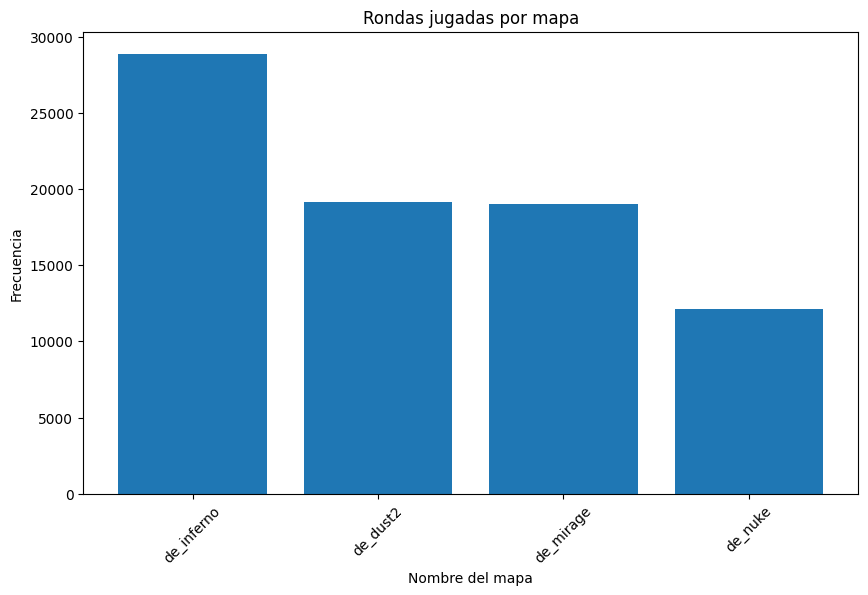

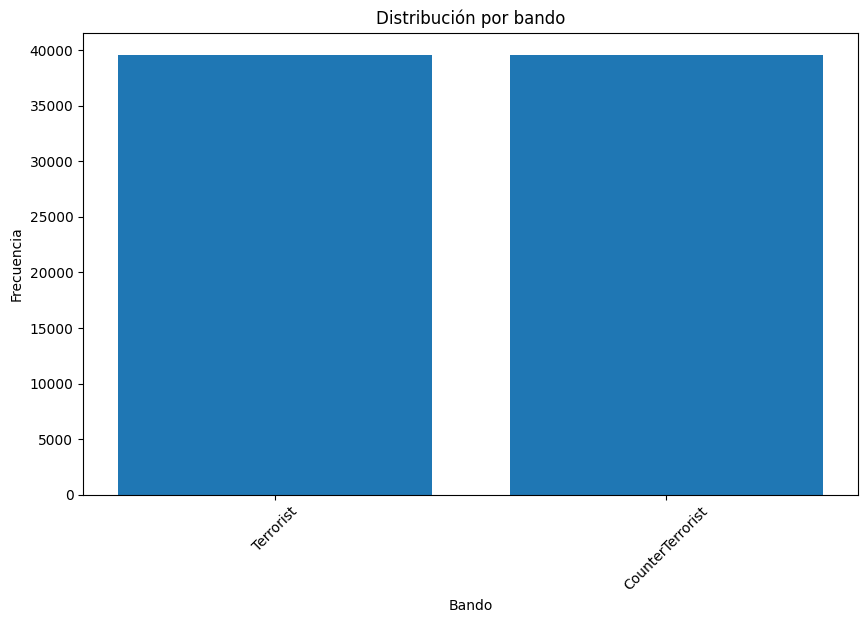

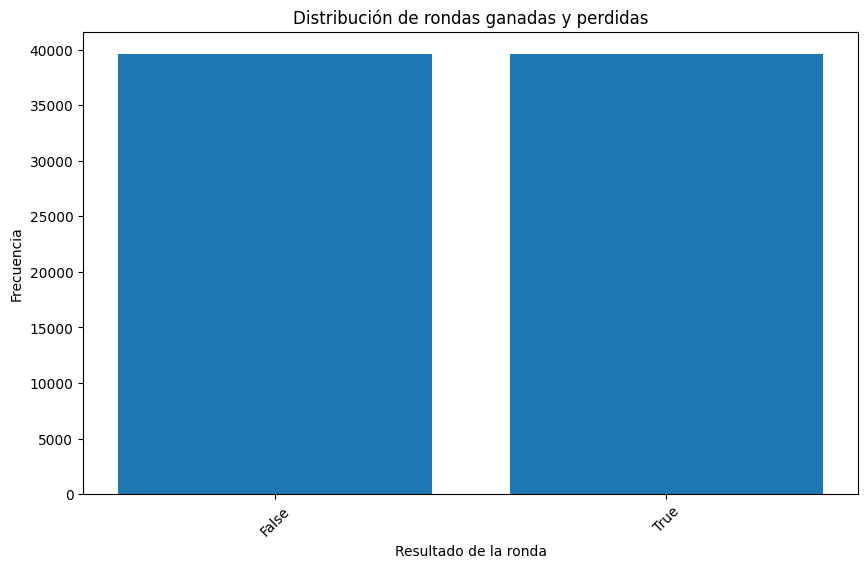

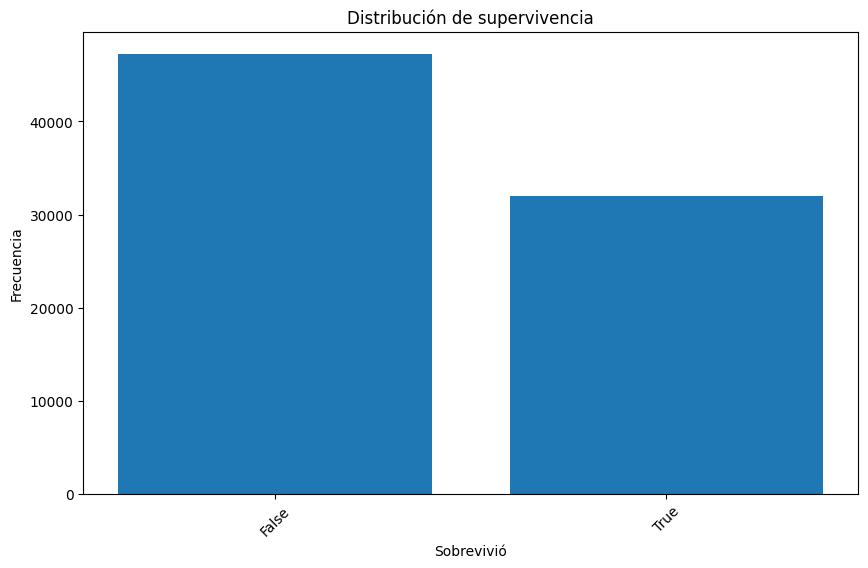

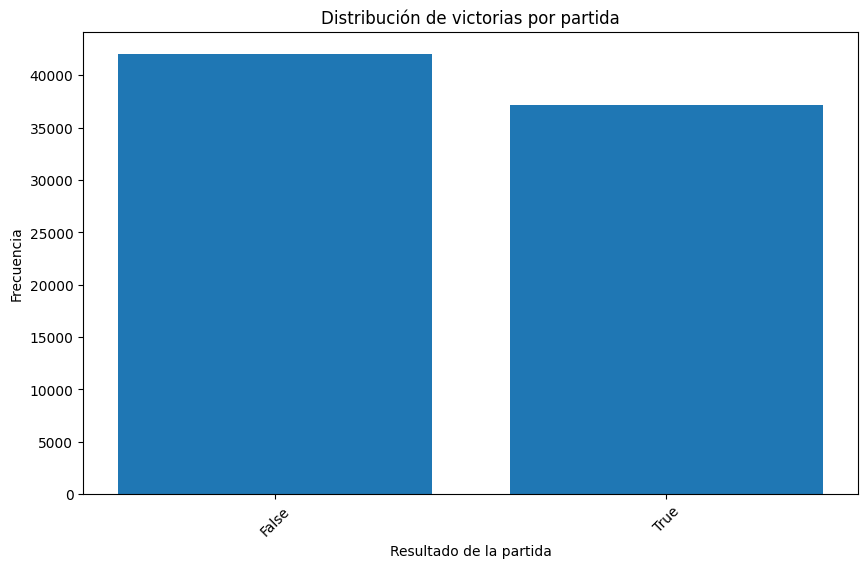

In [9]:
# Gráfico de barras
def bar_graph(columna, titulo=None, xlabel=None):
    f_type = df[columna].value_counts()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(f_type.index.astype(str), f_type.values)

    ax.set_ylabel("Frecuencia")
    ax.set_xlabel(xlabel if xlabel else columna)
    ax.set_title(titulo if titulo else f"Frecuencia de {columna}")

    plt.xticks(rotation=45)
    plt.show()

bar_graph("Map", titulo="Rondas jugadas por mapa", xlabel="Nombre del mapa")
bar_graph("Team", titulo="Distribución por bando", xlabel="Bando")
bar_graph("RoundWinner", titulo="Distribución de rondas ganadas y perdidas", xlabel="Resultado de la ronda")
bar_graph("Survived", titulo="Distribución de supervivencia", xlabel="Sobrevivió")
bar_graph("MatchWinner", titulo="Distribución de victorias por partida", xlabel="Resultado de la partida")

El análisis de frecuencias de las variables categóricas permite validar que el dataset presenta una distribución equilibrada en variables clave como el mapa, el equipo y el resultado de la ronda. Asimismo, variables como Survived permiten aproximar el comportamiento individual de los jugadores dentro de cada ronda.

Resultados:
- `Map` presenta una distribución relativamente equilibrada, aunque se observa una mayor proporción de partidas en _de_inferno_ (36.47%), seguido por _de_dust2_ (24.15%) y _de_mirage_ (24.03%). El mapa _de_nuke_ presenta una menor representación (15.35%). Esto indica que, si bien existe cierta variabilidad, el dataset no está completamente balanceado en términos de mapas, lo que podría influir levemente en el análisis.
- `Team`, se observa una distribución prácticamente equitativa entre los equipos Terrorista (50.01%) y CounterTerrorist (49.98%), lo que permite realizar comparaciones sin sesgos significativos entre ambos bandos.
- `RoundWinner` también presenta una distribución balanceada, con aproximadamente un 50% de rondas ganadas y perdidas. Este equilibrio es especialmente favorable para el desarrollo de modelos de clasificación, ya que evita problemas asociados al desbalance de clases.
- `Survived` muestra que aproximadamente un 40.35% de los jugadores sobreviven al final de la ronda, mientras que un 59.65% no lo hace. Esto es consistente con la dinámica del juego, donde la eliminación de jugadores es un evento frecuente durante las rondas.
- `MatchWinner` presenta una ligera inclinación hacia resultados negativos (53.08% frente a 46.91%), lo que indica una leve asimetría en la distribución de victorias a nivel de partida.
- `AbnormalMatch` presenta un 100% de falso, donde ninguna partida se vio comprometida a un fallo técnico.

Los gráficos de barras facilita la identificación de posibles desbalances en los datos, así como la comparación entre distintas categorías y confirman los resultados obtenidos mediante las tablas de frecuencia.

Variable: RLethalGrenadesThrown
Media: 0.50
Mediana: 0.00
Desviación estándar: 0.60



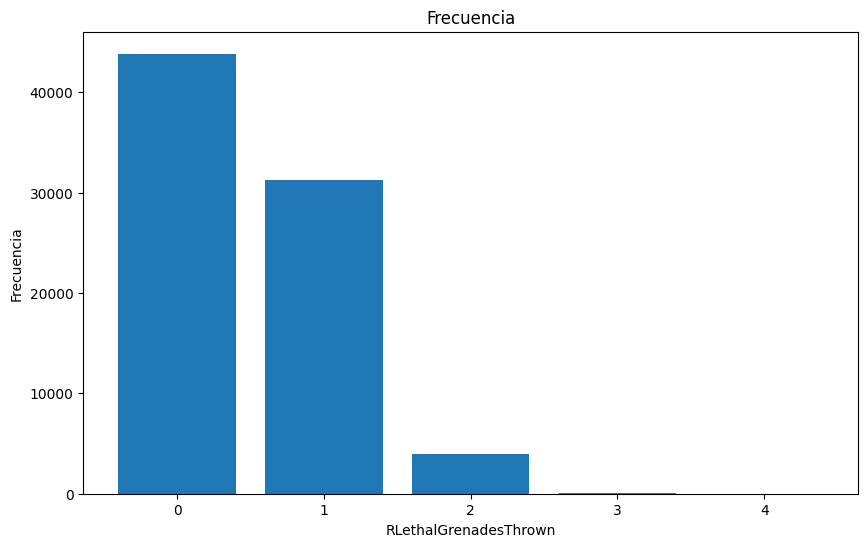

Variable: RNonLethalGrenadesThrown
Media: 1.26
Mediana: 1.00
Desviación estándar: 1.18



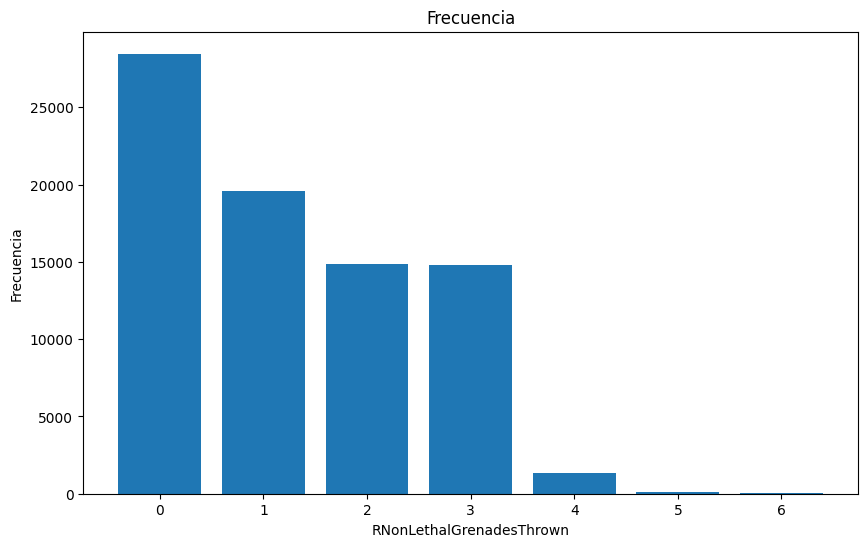

Variable: RoundKills
Media: 0.67
Mediana: 0.00
Desviación estándar: 0.88



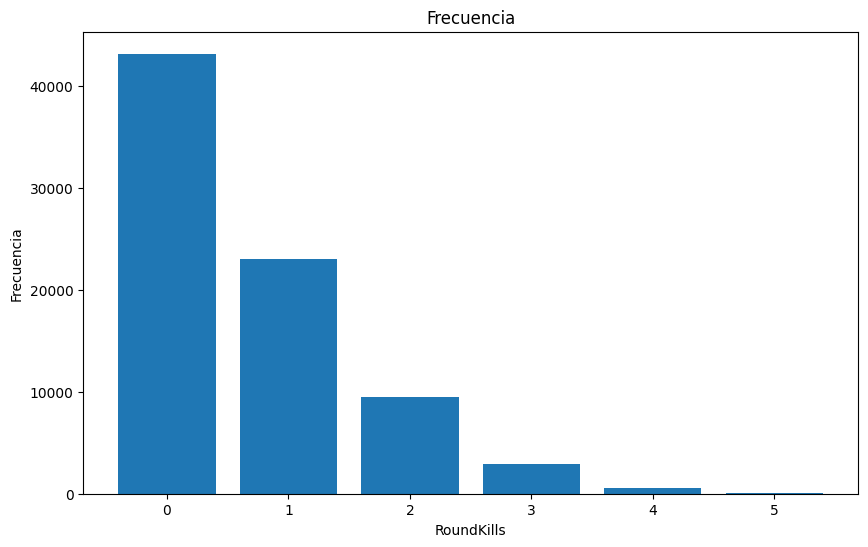

Variable: RoundAssists
Media: 0.15
Mediana: 0.00
Desviación estándar: 0.39



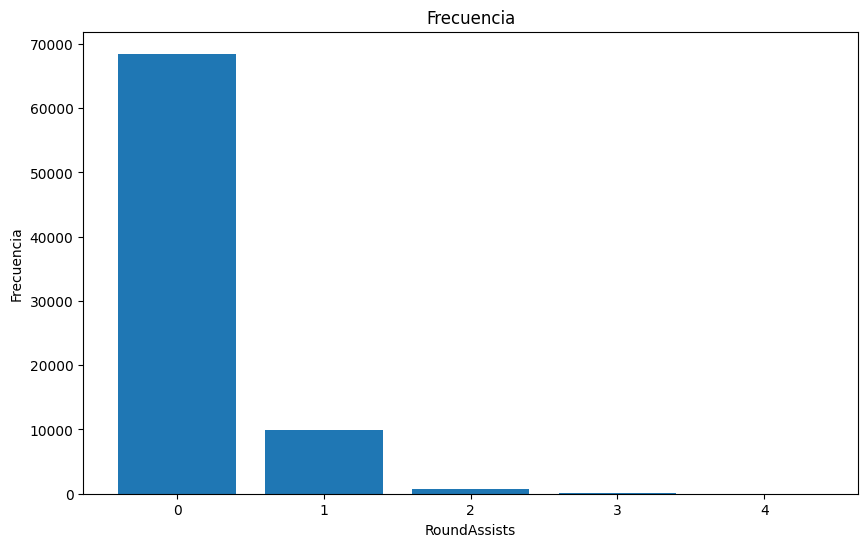

Variable: RoundHeadshots
Media: 0.30
Mediana: 0.00
Desviación estándar: 0.58



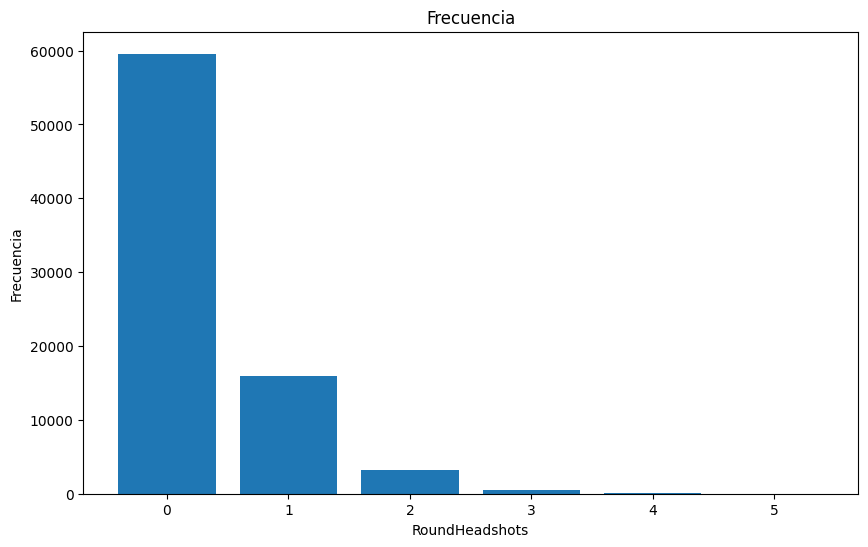

Variable: RoundFlankKills
Media: 0.10
Mediana: 0.00
Desviación estándar: 0.32



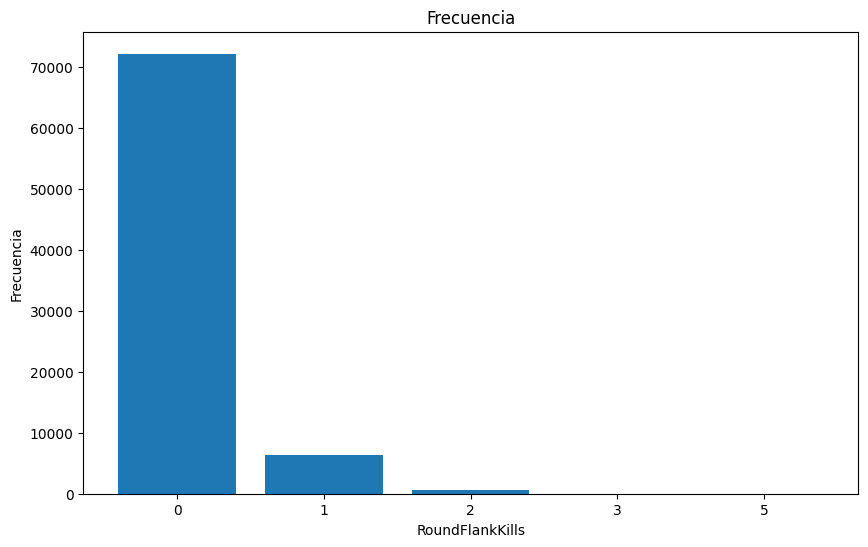

In [10]:
def bars_graphs(column):
    print(f"Variable: {column}")
    print(f"Media: {df[column].mean():.2f}")
    print(f"Mediana: {df[column].median():.2f}")
    print(f"Desviación estándar: {df[column].std():.2f}")
    print("")

    f_type = df[column].value_counts()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(f_type.index.astype(str), f_type.values)


    ax.set_ylabel("Frecuencia")
    ax.set_xlabel(column)
    ax.set_title(f"Frecuencia")
    plt.show()


bars_graphs("RLethalGrenadesThrown")
bars_graphs("RNonLethalGrenadesThrown")
bars_graphs("RoundKills")
bars_graphs("RoundAssists")
bars_graphs("RoundHeadshots")
bars_graphs("RoundFlankKills")

El análisis de las variables discretas relacionadas con el desempeño en ronda evidencia un patrón común caracterizado por una alta concentración de valores en cero y una disminución progresiva en frecuencias a medida que aumentan los valores.  
Este comportamiento se observa en variables como `RoundKills`, `RoundAssists`, `RoundHeadshots` y `RoundFlankKills`, lo que indica que la mayoría de los jugadores no genera impacto directo en cada ronda, mientras que un grupo reducido concentra los eventos relevantes.  
Por otro lado, las variables relacionadas con el uso de granadas muestran comportamientos diferenciados. Las granadas no letales presentan una distribución más equilibrada, mientras que las letales tienen una fuerte concentración en valores bajos, lo que sugiere un uso más limitado.  
En conjunto, estas distribuciones reflejan la naturaleza del juego, donde los eventos de alto impacto son poco frecuentes y dependen de situaciones específicas dentro de la ronda.  

Variable: PrimaryAssaultRifle
Media: 0.68
Mediana: 1.00
Desviación estándar: 0.46



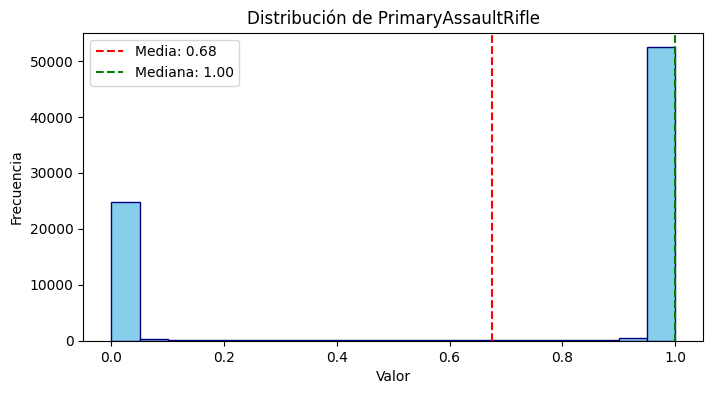

Variable: PrimarySniperRifle
Media: 0.09
Mediana: 0.00
Desviación estándar: 0.28



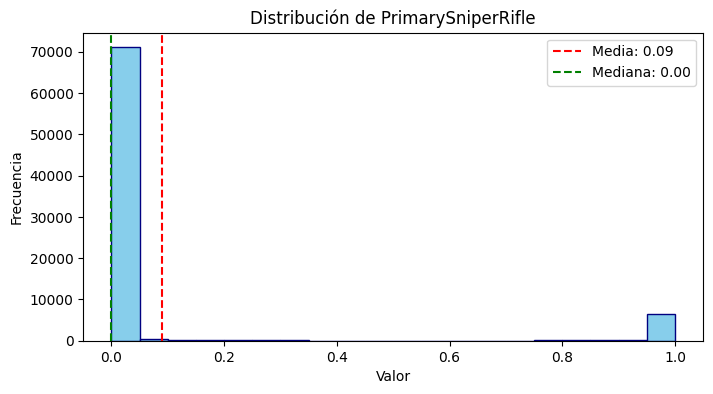

Variable: PrimaryHeavy
Media: 0.01
Mediana: 0.00
Desviación estándar: 0.08



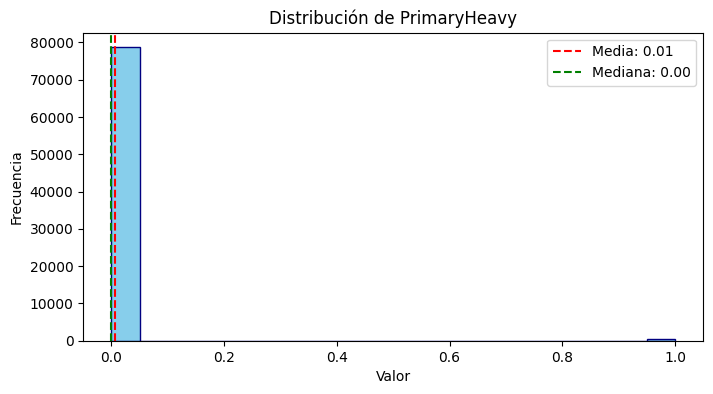

Variable: PrimarySMG
Media: 0.01
Mediana: 0.00
Desviación estándar: 0.08



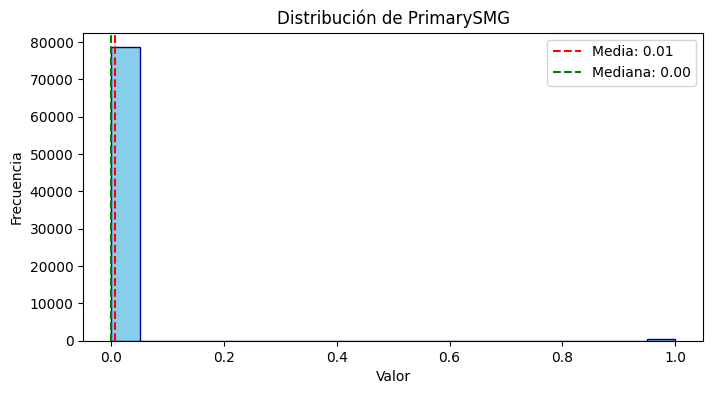

Variable: PrimaryPistol
Media: 0.22
Mediana: 0.00
Desviación estándar: 0.42



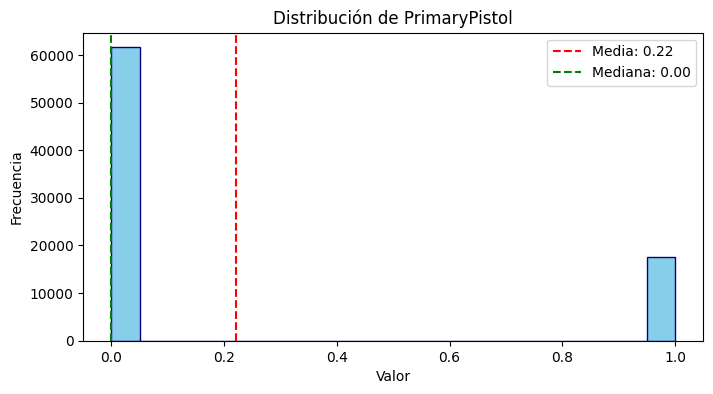

In [11]:
def graph_weapon_hist(column):
    serie = df[column]
    media = serie.mean()
    mediana = serie.median()

    print(f"Variable: {column}")
    print(f"Media: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Desviación estándar: {serie.std():.2f}")
    print("")

    plt.figure(figsize=(8,4))
    plt.hist(serie, bins=20, color='skyblue', edgecolor='navy')

    plt.axvline(media, color='red', linestyle="--", label=f"Media: {media:.2f}")
    plt.axvline(mediana, color='green',linestyle="--", label=f"Mediana: {mediana:.2f}")

    plt.title(f"Distribución de {column}")
    plt.xlabel("Valor")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

graph_weapon_hist("PrimaryAssaultRifle")
graph_weapon_hist("PrimarySniperRifle")
graph_weapon_hist("PrimaryHeavy")
graph_weapon_hist("PrimarySMG")
graph_weapon_hist("PrimaryPistol")

Las variables de armamento representan proporciones de uso dentro de una ronda, tomando valores entre 0 y 1, donde 0 indica que no se usó, 1 que solo se usó esa arma durante alguans rondas y los otros son porcentajes que pueden haber variado por ejemplo en rondas donde se combina el uso de dos armas.  
El análisis de los histogramas muestra que el rifle de asalto presenta una alta concentración de valores cercanos a 1, lo que indica que en una gran cantidad de rondas este tipo de arma es dominante.  
Por otro lado, armas como el rifle de francotirador (Snipper) presentan una fuerte concentración en valores cercanos a 0, lo que evidencia un uso más situacional. Las categorías Heavy y SMG muestran una utilización prácticamente nula, mientras que las pistolas presentan un uso intermedio asociado a contextos específicos como rondas económicas.  
En conjunto, estas distribuciones reflejan las decisiones tácticas de los jugadores en función del contexto de la ronda.

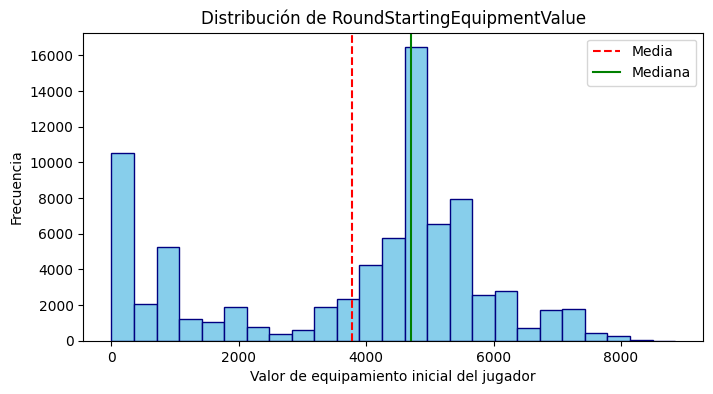

In [12]:
serie = df["RoundStartingEquipmentValue"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=25, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de RoundStartingEquipmentValue")
plt.xlabel("Valor de equipamiento inicial del jugador")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

La variable `RoundStartingEquipmentValue` presenta una distribución multimodal, evidenciada por la presencia de múltiples picos en distintos rangos de valores.
Estos picos corresponden a diferentes tipos de rondas dentro del juego, tales como rondas económicas (eco), rondas intermedias y rondas de compra completa (full buy). En particular, se observa una alta concentración de valores en torno a los niveles de equipamiento medio-alto, lo que indica que la mayoría de las rondas analizadas corresponden a situaciones de inversión significativa.

La media se encuentra por debajo de la mediana, lo que evidencia una distribución sesgada hacia valores bajos, influenciada por la presencia de rondas con bajo equipamiento.
En conjunto, esta variable refleja la estructura económica del juego y su impacto en el desarrollo de las rondas.

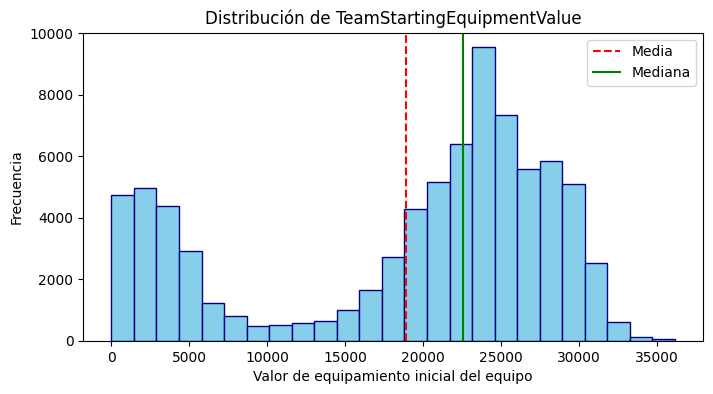

In [13]:
serie = df["TeamStartingEquipmentValue"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=25, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de TeamStartingEquipmentValue")
plt.xlabel("Valor de equipamiento inicial del equipo")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

La variable `TeamStartingEquipmentValue` presenta una distribución multimodal con una clara concentración en rangos de valores altos, correspondientes a rondas donde el equipo cuenta con equipamiento completo.
Se identifican distintos niveles de inversión económica que reflejan el estado financiero del equipo, destacando principalmente dos escenarios: rondas económicas con bajo equipamiento y rondas de compra completa con altos valores de inversión.

La media se encuentra por debajo de la mediana, lo que indica la presencia de valores bajos que influyen en la distribución, generando un sesgo hacia la izquierda.
En comparación con la variable individual, esta variable refleja de mejor manera la toma de decisiones colectivas del equipo, evidenciando patrones económicos más definidos.

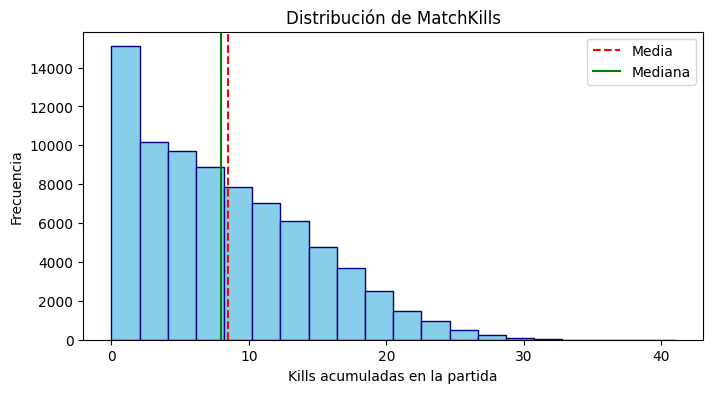

In [14]:
serie = df["MatchKills"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=20, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de MatchKills")
plt.xlabel("Kills acumuladas en la partida")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

La variable `MatchKills` presenta una distribución sesgada hacia la izquierda, caracterizada por una alta concentración de valores en rangos bajos y una disminución progresiva a medida que aumentan las kills acumuladas.

La media se encuentra levemente por encima de la mediana, lo que indica la presencia de jugadores con alto rendimiento que elevan el promedio general.
Cabe destacar que esta variable es de carácter acumulativo, por lo que su valor depende tanto del desempeño individual como de la duración de la partida, lo que introduce variabilidad adicional en su distribución. De momento nos indica que no es una variable confiable para un posterior desarrollo del modelo.

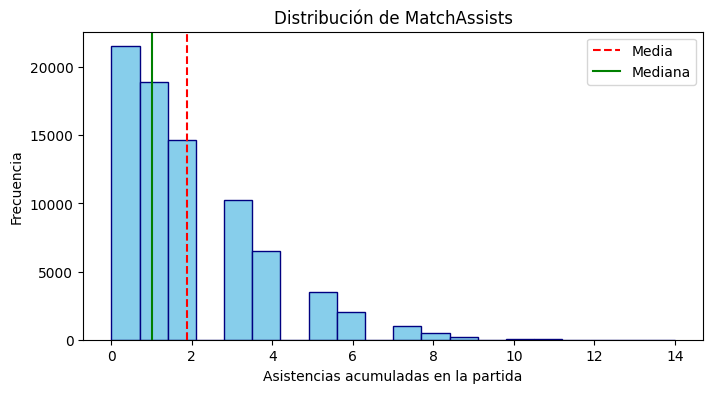

In [15]:
serie = df["MatchAssists"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=20, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de MatchAssists")
plt.xlabel("Asistencias acumuladas en la partida")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

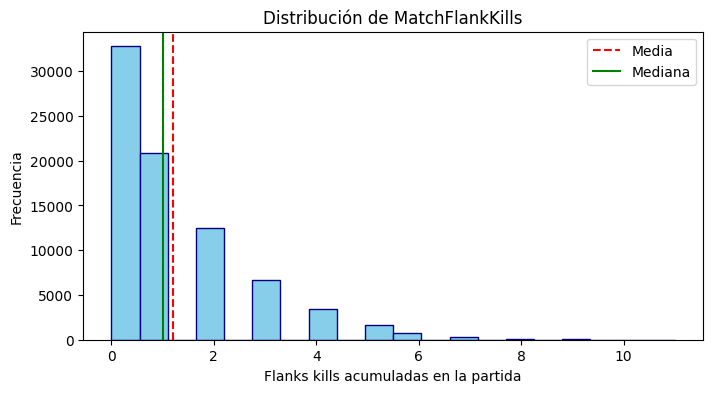

In [16]:
serie = df["MatchFlankKills"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=20, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de MatchFlankKills")
plt.xlabel("Flanks kills acumuladas en la partida")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

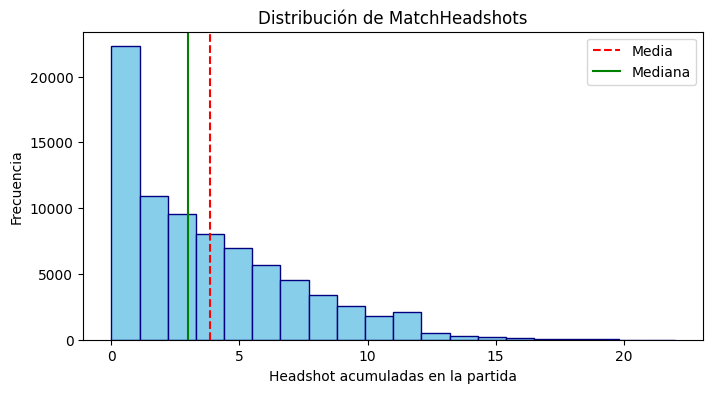

In [17]:
serie = df["MatchHeadshots"]
media = serie.mean()
mediana = serie.median()

plt.figure(figsize=(8,4))
plt.hist(serie, bins=20, color='skyblue', edgecolor='navy')

plt.axvline(media, color="red", linestyle="--", label="Media")
plt.axvline(mediana, color="green", linestyle="-", label="Mediana")

plt.title("Distribución de MatchHeadshots")
plt.xlabel("Headshot acumuladas en la partida")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Las demás variables que se pudieron visualizar en los histogramas muestran un comportamiento similar que se explica en parte por la naturaleza de la variable que es acumulativa mediante suceden las rondas con un sesgo hacia la izquierda, por que analizarla por si sola no nos entrega mucho valor, ya que son influenciadas por la duración de la partida y el desempeño individual.

Estos patrones evidencian que los datos no siguen distribuciones normales, lo que deberá ser considerado en las etapas posteriores del modelado.

En conjunto, las variables analizadas presentan comportamientos coherentes con el contexto del juego, sin evidencias de anomalías significativas.
A continuación revisaremos las variables que presentaron valores atipicos dentro de la funcion describe.

### 2.5. Exploración de valores atípicos
Como parte del estudio para identificar variables como potencialmente problemáticas, se utilizaron medidas de tendencia central y dispersión a través de la función `.agg()`.

Se utilizaron medidas de dispersión como la desviación estándar junto con cuartiles e IQR para detectar valores atípicos. Mientras la desviación estándar permitió evaluar la variabilidad general de los datos, el IQR facilitó la identificación de outliers sin asumir una distribución normal.

In [18]:
def resumen_estadistico(columna):
    resumen = df[columna].agg([
        "mean",
        "median",
        "std",
        "var",
        "min",
        "max"
    ])

    cuartiles = df[columna].quantile([0.25, 0.5, 0.75])

    print(f"\nVariable: {columna}")
    print(resumen)
    print("\nCuartiles:")
    print(cuartiles)

resumen_estadistico("TimeAlive")
resumen_estadistico("FirstKillTime")
resumen_estadistico("TravelledDistance")


Variable: TimeAlive
mean        72.795720
median      69.239615
std         48.321035
var       2334.922434
min          0.000000
max       2990.560394
Name: TimeAlive, dtype: float64

Cuartiles:
0.25    47.080072
0.50    69.239615
0.75    92.647813
Name: TimeAlive, dtype: float64

Variable: FirstKillTime
mean        58.066821
median      54.774193
std         32.424435
var       1051.343985
min          0.000000
max        545.034851
Name: FirstKillTime, dtype: float64

Cuartiles:
0.25    36.273243
0.50    54.774193
0.75    79.065900
Name: FirstKillTime, dtype: float64

Variable: TravelledDistance
mean      1.041888e+05
median    8.601557e+04
std       3.543487e+05
var       1.255630e+11
min       0.000000e+00
max       3.964645e+07
Name: TravelledDistance, dtype: float64

Cuartiles:
0.25     58982.548256
0.50     86015.571135
0.75    121396.620621
Name: TravelledDistance, dtype: float64



- `TimeAlive`: presenta una distribución relativamente estable en su rango central, evidenciado por la cercanía entre la media y la mediana. Sin embargo, el valor máximo observado se encuentra extremadamente alejado del tercer cuartil, lo que indica la presencia de valores atípicos significativos. Dado que estos valores superan ampliamente la duración esperada de una ronda, es probable que correspondan a errores de medición o inconsistencias en los datos.
- `FirstKillTime`: presenta una distribución coherente en su rango central, con valores concentrados dentro de los límites esperados para una ronda. No obstante, el valor máximo observado excede ampliamente el rango definido por los cuartiles, lo que sugiere la presencia de valores atípicos que no representan correctamente el comportamiento real del juego.
- `TravelledDistance`: presenta una alta dispersión, evidenciada por la gran diferencia entre la media y la mediana, así como por su elevada desviación estándar. El valor máximo observado es considerablemente mayor al tercer cuartil, lo que indica una distribución fuertemente sesgada y la presencia de valores extremos que afectan significativamente las métricas estadísticas. Esto sugiere que la variable contiene outliers que no representan el comportamiento típico de los jugadores.

In [19]:
def detectar_outliers_iqr(columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"Variable: {columna}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Porcentaje de outliers: {len(outliers) / len(df) * 100:.2f}%")
    print("")

detectar_outliers_iqr("TimeAlive")
detectar_outliers_iqr("FirstKillTime")
detectar_outliers_iqr("TravelledDistance")

Variable: TimeAlive
Q1: 47.08
Q3: 92.65
IQR: 45.57
Límite inferior: -21.27
Límite superior: 161.00
Porcentaje de outliers: 0.75%

Variable: FirstKillTime
Q1: 36.27
Q3: 79.07
IQR: 42.79
Límite inferior: -27.92
Límite superior: 143.25
Porcentaje de outliers: 0.62%

Variable: TravelledDistance
Q1: 58982.55
Q3: 121396.62
IQR: 62414.07
Límite inferior: -34638.56
Límite superior: 215017.73
Porcentaje de outliers: 1.59%



Revisemos el IQR en mayor detalle, este analisis nos permite identificar valores extremos sin asumir que los datos siguen una distribución normal (Ocupamos la constante de 1.5 ya que es un valor estandar y usual).  
El análisis permitió identificar que las variables `TimeAlive`, `FirstKillTime` y `TravelledDistance` presentan un porcentaje reducido de valores atípicos, inferior al 2% en todos los casos. Sin embargo, estos valores extremos se encuentran considerablemente alejados del rango normal definido por los cuartiles, lo que indica que no corresponden al comportamiento esperado dentro del contexto del juego.     
En particular, las variables relacionadas con el tiempo presentan valores máximos que superan ampliamente la duración posible de una ronda, mientras que la variable `TravelledDistance` muestra una dispersión considerablemente elevada.  
Estos resultados sugieren la presencia de datos inconsistentes o errores de registro, por lo que será necesario considerar su tratamiento en etapas posteriores del proyecto.  

Revisando la documentacion del desarrollador de valve (https://developer.valvesoftware.com/wiki/Counter-Strike:_Global_Offensive/Mapper%27s_Reference)  

Se puede apreciar que la variable `TravelledDistance`, se puede medir en Hammer Unit, una unidad de medida interna usada en CS:GO. Considerando que aproximadamente 1 metro equivale a 52 unidades, los valores promedio observados en el dataset se encuentran dentro de rangos. Sin embargo, se identifica el valor máximos muy elevados que esto parece imposible para el mismo juego, es importante en tener en consideración para la siguiente etapa.


### 2.6. Identificación de valores nulos
Se realizó un análisis de valores nulos por variable. El resultado muestra que no existen valores faltantes en el dataset.

In [20]:
# Revisemos que si existen columnas con valores nulos
miss = df.isnull().sum()
miss[miss > 0]
# OUTPUT: No hay nos entrega un array sin columnas, vacio por lo que no hay datos nulos

Series([], dtype: int64)

### 2.7. Estudio de KPIs y correlación entre los datos del dataset

In [21]:
# porcentaje de rondas ganadas
pct_round_winner = df["RoundWinner"].value_counts(normalize=True)

# promedio de kills
mean_round_kills = df["RoundKills"].mean()

# promedio de granadas
mean_lethal_grenades = df["RLethalGrenadesThrown"].mean()
mean_non_lethal_grenades = df["RNonLethalGrenadesThrown"].mean()

# equipamiento promedio
mean_start_equip_value = df["RoundStartingEquipmentValue"].mean()

print(f"Porcentaje de rondas ganadas: {pct_round_winner}")
print("")
print(f"Promedio de kills por ronda: {mean_round_kills}")
print("")
print(f"Promedio de granadas letales por ronda: {mean_lethal_grenades}")
print("")
print(f"Promedio de granadas no letales por ronda: {mean_non_lethal_grenades}")
print("")
print(f"Promedio del equipamiento llevado por el jugador al inicio de la ronda: {mean_start_equip_value}")



Porcentaje de rondas ganadas: RoundWinner
False    0.500133
True     0.499867
Name: proportion, dtype: float64

Promedio de kills por ronda: 0.6713493437093372

Promedio de granadas letales por ronda: 0.49866720567985146

Promedio de granadas no letales por ronda: 1.2580567732481018

Promedio del equipamiento llevado por el jugador al inicio de la ronda: 3778.1086953775407


El promedio de rondas ganadas se puede ver que es un resultado equilibrado, donde son más rondas perdidas en total.  
La cantidad promedio de eliminaciones por ronda es inferior a 1, lo que refleja que no todos los jugadores alcanzan a eliminar en cada ronda. Esto es posible explicarse por la dinámica del juego, donde el desempeño individual es diferente en cada jugador.  
El uso de granadas letales presenta un promedio a 0.49 por ronda, lo que indica que su utilización no es constante y depende del contexto de la partida.  
Las granadas no letales presentan un uso promedio superior al de las granadas letales, lo que sugiere que cumplen un rol táctico más frecuente dentro de las rondas, como bloquear visión o facilitar el posicionamiento.  
El valor promedio del equipamiento inicial del jugador es cercano a 3.778, lo que refleja variabilidad en la economía entre rondas. Esta variable es relevante para el análisis, ya que permite distinguir entre rondas con bajo presupuesto (eco) y rondas con equipamiento completo (fullbuy).  

¿Será posible que las rondas más ganadas son donde hay más asesinatos?


In [22]:
df.groupby("RoundWinner")["RoundKills"].mean()

RoundWinner
False    0.908687
True     0.433886
Name: RoundKills, dtype: float64

A partir del resultado podemos evaluar que no necesariamente está ligado, esto es posible ya que al ser un juego táctico no solo se mide el desempeño de combate, si no también el de estrategia. La victoria no depende exclusivamente de eliminar al equipo, sino también del cumplimiento de objetivos. Esto permite que un equipo gane una ronda con menor cantidad de eliminaciones.

Además, al tratarse de datos a nivel de jugador, los equipos que pierden pueden acumular más eliminaciones en total antes de ser eliminados, lo que influye en el promedio observado.

Por lo tanto, la cantidad de eliminaciones, por sí sola, no es suficiente para predecir el resultado de una ronda, y debe analizarse en conjunto con otras variables.


Identifiquemos la relación entre las variables del dataset y el resultado de la ronda (nuestro target) para esto se utilizará la correlación de Pearson, ya que nos permite medir la relación lineal entre variables, entregando valores entre -1 y 1, entre más cercano al 1 es una relacion positiva fuerte (si una variable aumenta la otra igual). Por el contrario, si es cercano a -1 indica una relación inversa (el aumento de una variable se asocia a la disminución de la otra). En cambio los valores que estén cercanos a 0 son una relación débil o inexistente.

Por lo mismo, la correlación de Pearson será utilizada para analizar cómo variables relacionadas con el desempeño del jugador, el uso de recursos y el equipamiento se relacionan con la variable objetivo "RoundWinner".

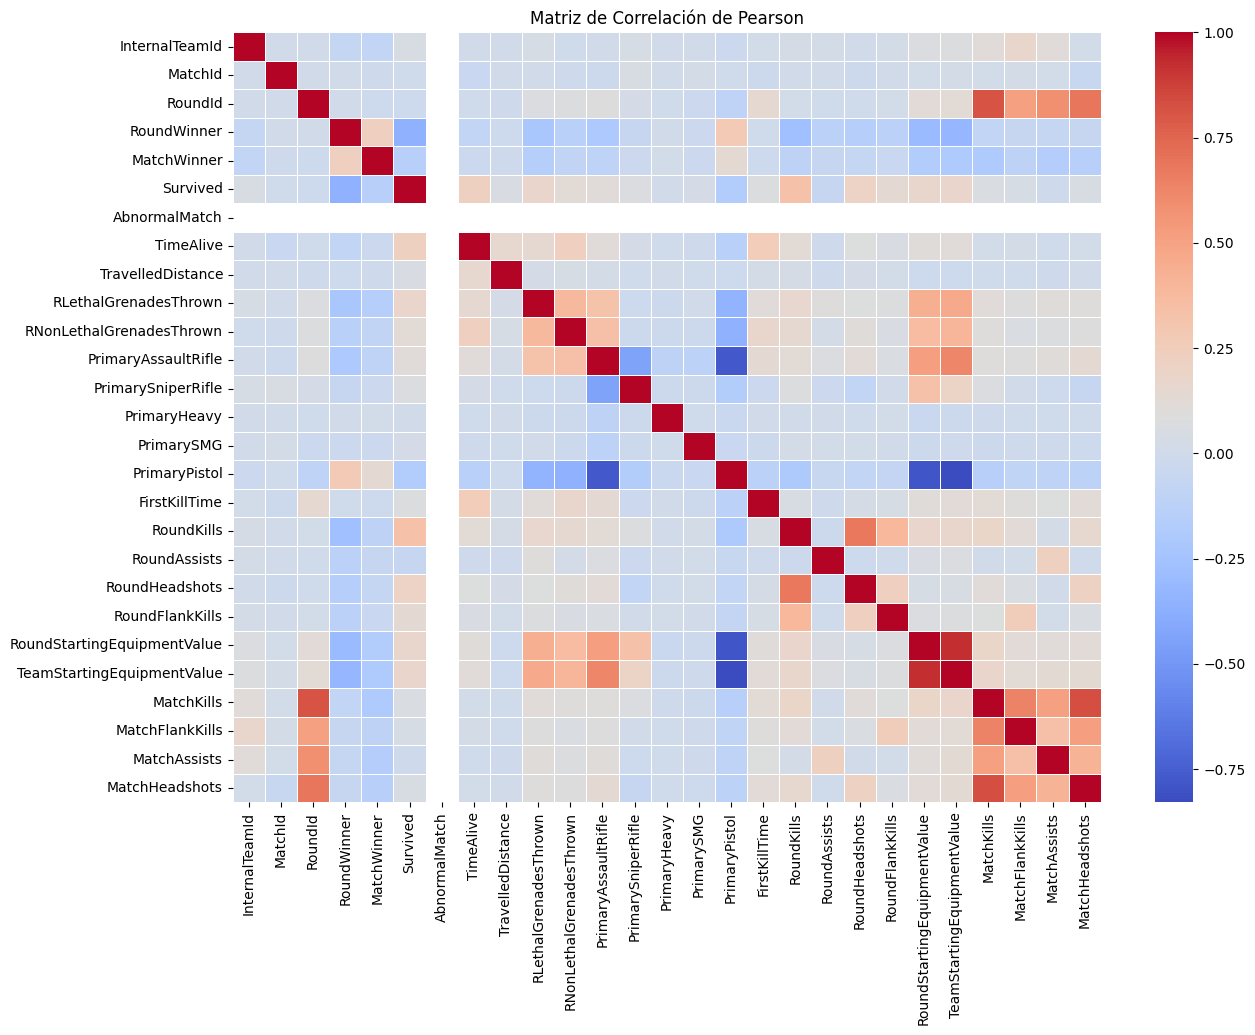

In [23]:
corr = df.corr(numeric_only=True)

corr["RoundWinner"].sort_values(ascending=False)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlación de Pearson")
plt.show()

Se construyó una matriz de correlación de Pearson con el objetivo de analizar la relación lineal entre las variables del dataset.

En general, se observó que la mayoría de las variables presentan correlaciones bajas, lo que indica que no existe una dependencia lineal fuerte entre ellas. Esto es consistente con la naturaleza compleja del problema, donde múltiples factores influyen en el resultado de una ronda.

Se identificaron correlaciones altas entre variables acumulativas a nivel de partida (como `MatchKills`, `MatchAssists` y `MatchHeadshots`).

Por otro lado, variables relacionadas con el desempeño en la ronda, como `RoundKills` y `RoundHeadshots`, presentaron correlaciones positivas con la variable objetivo `RoundWinner`, lo que indica que un mejor rendimiento individual se asocia con una mayor probabilidad de ganar la ronda.

Finalmente, se observan correlaciones moderadas entre variables económicas, reflejando la relación entre el equipamiento individual y del equipo.

Para comprender mejor los datos y hacer descubrimientos de negocio, definiremos y analizaremos distintos indicadores clave de desempeño (KPI). Estos nos permitiran resumir información relevante sobre variables asociadas al desempeño de los jugadores, el uso de recursos y el contexto de la partida, facilitando la identificación de patrones y diferencias entre rondas ganadas y perdidas.

Seleccionaremos KPIs que se enfoquen en variables relacionadas con el equipamiento, el uso de granadas, el tipo de armamento, la supervivencia y el desempeño individual, ya que estas dimensiones son fundamentales para el análisis planteado en este proyecto.

De esta forma podremos analizar la relación entre dichas variables y la probabilidad de victoria, aportando evidencia para las hipótesis definidas.

In [24]:
round_winner_count = df["RoundWinner"].value_counts()
round_winner_ratio = df["RoundWinner"].value_counts(normalize=True)

total_partidas = df["MatchId"].nunique()
total_rondas = df[["MatchId", "RoundId"]].drop_duplicates().shape[0]
total_mapas = df["Map"].nunique()

kpi_by_round_result = df.groupby("RoundWinner").agg({
    "RoundStartingEquipmentValue": "mean",
    "TeamStartingEquipmentValue": "mean",
    "RLethalGrenadesThrown": "mean",
    "RNonLethalGrenadesThrown": "mean",
    "Survived": "mean",
    "TimeAlive": "mean",
    "FirstKillTime": "mean",
    "RoundKills": "mean",
    "RoundAssists": "mean",
    "RoundHeadshots": "mean"
})

weapon_kpi_by_round_result = df.groupby("RoundWinner")[[
    "PrimaryAssaultRifle",
    "PrimarySniperRifle",
    "PrimaryHeavy",
    "PrimarySMG",
    "PrimaryPistol"
]].mean()

# A pesar de que no son variables de combate, queremos saber como es el promedio en relación al mapa y equipo
winrate_by_map = df.groupby("Map")["RoundWinner"].mean()
winrate_by_team = df.groupby("Team")["RoundWinner"].mean()


df_grenades = df[[
    "RoundWinner",
    "RLethalGrenadesThrown",
    "RNonLethalGrenadesThrown"
]].copy()

df_grenades["TotalGrenadesThrown"] = (
    df_grenades["RLethalGrenadesThrown"] +
    df_grenades["RNonLethalGrenadesThrown"]
)

grenade_kpi = df_grenades.groupby("RoundWinner")[[
    "RLethalGrenadesThrown",
    "RNonLethalGrenadesThrown",
    "TotalGrenadesThrown"
]].mean()



print(f"Cantidad total de rondas ganadas y perdidas:\n{round_winner_count}")
print(f"Proporción de rondas ganadas y perdidas:\n{round_winner_ratio}")
print(f"Total de partidas únicas identificadas con MatchId: {total_partidas}")
print(f"Total de rondas únicas identificadas con MatchId y RoundId: {total_rondas}")
print(f"Total de mapas presentes en el dataset: {total_mapas}")
print("")

print("Promedio de variables de desempeño y recursos según resultado de la ronda")
display(kpi_by_round_result)
print("")

print("Promedio de uso de armamento según resultado de la ronda")
display(weapon_kpi_by_round_result)
print("")

print("Proporción de victorias por mapa")
display(winrate_by_map)
print("")

print("Proporción de victorias por bando")
display(winrate_by_team)
print("")

print("Promedio de uso de granadas según resultado de la ronda")
display(grenade_kpi)
print("")





Cantidad total de rondas ganadas y perdidas:
RoundWinner
False    39589
True     39568
Name: count, dtype: int64
Proporción de rondas ganadas y perdidas:
RoundWinner
False    0.500133
True     0.499867
Name: proportion, dtype: float64
Total de partidas únicas identificadas con MatchId: 333
Total de rondas únicas identificadas con MatchId y RoundId: 7916
Total de mapas presentes en el dataset: 4

Promedio de variables de desempeño y recursos según resultado de la ronda


,RoundStartingEquipmentValue,TeamStartingEquipmentValue,RLethalGrenadesThrown,RNonLethalGrenadesThrown,Survived,TimeAlive,FirstKillTime,RoundKills,RoundAssists,RoundHeadshots
RoundWinner,,,,,,,,,,
False,4416.753391,22083.518149,0.631665,1.426331,0.579808,76.824427,58.179515,0.908687,0.193160,0.391068
True,3139.125051,15695.054084,0.365598,1.089694,0.227179,68.764874,57.954067,0.433886,0.099171,0.211989



Promedio de uso de armamento según resultado de la ronda


,PrimaryAssaultRifle,PrimarySniperRifle,PrimaryHeavy,PrimarySMG,PrimaryPistol
RoundWinner,,,,,
False,0.769151,0.106598,0.005947,0.009537,0.108768
True,0.581526,0.073073,0.005981,0.004554,0.334867



Proporción de victorias por mapa


Map
de_dust2      0.500000
de_inferno    0.499809
de_mirage     0.499711
de_nuke       0.500041
Name: RoundWinner, dtype: float64


Proporción de victorias por bando


Team
CounterTerrorist    0.423076
Terrorist           0.576606
Name: RoundWinner, dtype: float64


Promedio de uso de granadas según resultado de la ronda


,RLethalGrenadesThrown,RNonLethalGrenadesThrown,TotalGrenadesThrown
RoundWinner,,,
False,0.631665,1.426331,2.057996
True,0.365598,1.089694,1.455292


A partir de los indicadores calculados, es posible identificar distintos patrones en el comportamiento del dataset y su relación con el resultado de las rondas.

En primer lugar, la distribución de la variable `RoundWinner` se encuentra prácticamente balanceada, con una proporción cercana al 50% entre rondas ganadas y perdidas.

En cuanto a la robustez de la muestra, el dataset contiene 79,157 registros correspondientes a 333 partidas distintas y 7,916 rondas únicas, distribuidas en 4 mapas.

Al analizar las variables de desempeño y recursos según el resultado de la ronda: el valor promedio del equipamiento inicial, así como el uso de granadas, es mayor en rondas perdidas. Esto indica que una mayor inversión económica o un mayor uso de recursos no garantizan la victoria, lo que refleja la importancia de factores tácticos y estratégicos dentro del juego.

De forma similar, variables como `RoundKills`, `TimeAlive` y `Survived` presentan valores promedio mayores en rondas perdidas. Este comportamiento se explica por la estructura del dataset, el cual se encuentra a nivel de jugador por ronda. En este contexto, los equipos perdedores pueden acumular más acciones individuales antes de ser eliminados, mientras que los equipos ganadores pueden asegurar la victoria mediante el cumplimiento de objetivos sin necesidad de maximizar estas métricas.

En relación con el armamento, se observa que los rifles de asalto son más utilizados en rondas perdidas, mientras que las pistolas tienen mayor presencia en rondas ganadas. Este resultado puede estar asociado a la dinámica económica del juego, donde equipos con menor equipamiento logran victorias mediante estrategias eficientes, como ocurre en rondas de bajo presupuesto.

Por otro lado, el análisis por mapa muestra una distribución equilibrada de victorias. Sin embargo, al analizar el bando, se observa una mayor proporción de victorias para el equipo Terrorista, lo que podría reflejar una ventaja estructural en los datos o en las condiciones del juego analizado.

Un resultado particularmente relevante se observa al analizar la relación entre el equipamiento del equipo y la probabilidad de victoria. Se identifica que los rangos más bajos de equipamiento presentan una mayor tasa de victoria, lo que refuerza la idea de que la economía, por sí sola, no determina el resultado de la ronda.

Finalmente, el uso total de granadas también es mayor en rondas perdidas, lo que sugiere que el uso de recursos debe analizarse en términos de efectividad y no solo de cantidad.

En conjunto, estos resultados evidencian que el resultado de una ronda en CS:GO no depende de una única variable, sino de la interacción de múltiples factores.

### Conclusión de Data Understanding

A partir del análisis exploratorio realizado, se identificaron distintos patrones relevantes en el dataset. Las variables presentan principalmente distribuciones no normales, caracterizadas por sesgos hacia valores bajos, presencia de múltiples modos y comportamiento acumulativo en algunas métricas.

Asimismo, se detectó la presencia de valores atípicos en variables como TimeAlive, FirstKillTime y TravelledDistance.

Las variables económicas evidencian una estructura basada en estados discretos del juego (eco, semi-buy y full buy), mientras que las variables de desempeño reflejan una distribución desigual del impacto entre los jugadores.

Estos hallazgos permiten comprender mejor la naturaleza de los datos y serán fundamentales para definir las transformaciones necesarias en la siguiente etapa de preparación de datos.

Los patrones observados sugieren que algunas variables podrían requerir transformaciones, tales como normalización, discretización o tratamiento de outliers.

## Fase 3: Data Preparation

En esta fase se ejecutan todas las transformaciones necesarias para dejar el dataset listo para la etapa de Modeling. El objetivo es aplicar técnicas de limpieza, tratamiento de valores atípicos, codificación de variables categóricas y estandarización de variables numéricas, guiados por el objetivo de negocio definido: **predecir si un jugador ganará una ronda (`RoundWinner`) en función del uso de armamento, granadas, comportamiento individual, mapa y bando**.

Las transformaciones se aplican en el siguiente orden:

1. Análisis y eliminación de columnas con justificación extensa
2. Tratamiento de outliers
3. Verificación de valores nulos
4. Selección de features significativos por Correlación de Pearson
5. Encoding de variables categóricas
6. Estandarización de variables numéricas (Scaling)
7. Construcción y exportación del dataset final

In [25]:
# Copia de trabajo para no modificar el dataset original en ninguna etapa
df_prepared = df.copy()
print(f"Dataset de trabajo inicializado. Shape: {df_prepared.shape}")
print(f"Columnas disponibles:\n{list(df_prepared.columns)}")

Dataset de trabajo inicializado. Shape: (79157, 29)
Columnas disponibles:
['Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner', 'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance', 'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime', 'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills', 'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills', 'MatchFlankKills', 'MatchAssists', 'MatchHeadshots']


## 3.1 Análisis y Eliminación de Columnas

Antes de eliminar cualquier columna, es fundamental entender la **semántica del dataset**:

- Cada fila representa el **desempeño de un jugador individual en una ronda específica**.
- Los jugadores **mantienen su posición de ID a lo largo de las rondas**: el jugador 1 de la ronda 1 sigue siendo el jugador 1 en la ronda 2, y así sucesivamente. Esto permite rastrear la evolución individual de cada jugador a lo largo del partido.
- Un **Match** (partida) está compuesto por múltiples **Rounds** (rondas). El ganador del Match es el equipo que primero alcanza **16 victorias de ronda**. En caso de empate a 15 victorias, se activa el **overtime**, donde se continúa jugando hasta que un equipo logre una diferencia de 2 victorias consecutivas. Se eliminan sobre las 30 rondas para evitar datos anomalos.
- Las columnas `Match*` (MatchKills, MatchFlankKills, MatchAssists, MatchHeadshots) representan estadísticas **acumuladas desde la ronda 1 hasta la ronda actual**, por lo que su valor aumenta conforme avanza la partida y es información **disponible en tiempo real** al momento de cada ronda.

Bajo este entendimiento, el criterio para eliminar columnas es estricto y requiere justificación explícita.



In [26]:
# Capeo de RoundId a 30 (evitar datos anomalos de overtime)
registros_antes = len(df_prepared)
df_prepared = df_prepared[df_prepared['RoundId'] <= 30].copy()
registros_despues = len(df_prepared)

print(f"Capeo de rondas aplicado: RoundId <= 30")
print(f"Registros antes:      {registros_antes:,}")
print(f"Registros despues:    {registros_despues:,}")
print(f"Registros eliminados: {registros_antes - registros_despues:,} "
      f"({(registros_antes - registros_despues)/registros_antes*100:.3f}%)")


Capeo de rondas aplicado: RoundId <= 30
Registros antes:      79,157
Registros despues:    79,047
Registros eliminados: 110 (0.139%)


In [27]:
columns_to_drop = [
    "AbnormalMatch",
    "InternalTeamId",
    "MatchId",
    "RoundId",
    "MatchWinner",
    "FirstKillTime",
    "MatchKills",
    "MatchFlankKills",
    "MatchAssists",
    "MatchHeadshots"
]

df_prepared = df_prepared.drop(columns=columns_to_drop)

**Justificación:**
La columna `AbnormalMatch` tiene **varianza cero**: todos sus 79.157 registros contienen el valor `False`. Una variable constante es, por definición, incapaz de aportar información discriminativa, su coeficiente de correlación con cualquier otra variable resulta en `NaN` (división por cero en la fórmula de Pearson), lo cual fue confirmado en la fase de Data Understanding. Incluirla en el modelo no genera error, pero sí ruido innecesario y puede afectar el rendimiento computacional sin ningún beneficio predictivo.

**Justificación:**
`MatchId` es un **identificador único de partida**, un número entero secuencial asignado administrativamente que no contiene información sobre el desarrollo del juego ni sobre las características de los jugadores. Su valor numérico (ej. Match 4, Match 100, Match 511) no tiene ninguna relación ordinal ni semántica con el resultado de una ronda: el Match número 4 no es "más difícil" o "más competitivo" que el Match número 400. Incluirlo en el modelo provocaría que el algoritmo intentara aprender patrones espurios a partir de un número de referencia administrativa, lo que deterioraría la capacidad de generalización a nuevas partidas. Su función es la de **llave de agrupación** para análisis exploratorio, no un predictor.

**Justificación:**
`InternalTeamId` toma únicamente dos valores: `1` y `2`, que representan cuál de los dos equipos de la partida es el que está siendo analizado en ese registro. Al hacer la tabla cruzada con la columna `Team`, se confirma que esta variable es **completamente redundante** con `Team` (Terrorist / CounterTerrorist): el InternalTeamId 1 siempre corresponde a un bando y el 2 al otro dentro de cada Match. La columna `Team` ya captura esta distinción de forma semánticamente más rica, identificando el **rol táctico del bando** (sus objetivos, mecánicas y economía particular), que es la información que realmente importa para el modelo. Mantener `InternalTeamId` introduciría **multicolinealidad perfecta** con `Team`, distorsionando los coeficientes en modelos lineales. Si bien los jugadores mantienen su posición de ID a lo largo de las rondas, esta continuidad individual no está capturada por `InternalTeamId` (que es del equipo, no del jugador), sino que debe inferirse a partir de la combinación de `MatchId` + `RoundId` + `Team`, que se usan en la fase exploratoria pero no como features del modelo.

**Justificación:**
Justificación para `RoundId`: RoundId es un contador secuencial dentro de un MatchId que identifica el número de ronda dentro de la partida. Previo a su eliminación, esta columna fue utilizada para filtrar las rondas de overtime (rondas con `RoundId` > 30), ya que las rondas adicionales presentan dinámicas de juego atípicas —equipamiento limitado, reglas económicas distintas— que introducen sesgos no representativos del comportamiento general. Finalizado ese preprocesamiento, `RoundId` fue eliminado del modelo porque su valor numérico por sí solo carece de poder predictivo generalizable entre partidas: la relación entre el número de ronda y el ganador es débil y capturada de forma más robusta por variables acumuladas como `MatchKills` o el estado económico del equipo.

**Justificación para `MatchWinner`:**
`MatchWinner` indica si el equipo del jugador ganó la partida completa. Aunque tiene una correlación positiva con `RoundWinner`, `MatchWinner` representa el *resultado de toda la partida*, que no se conoce al comienzo de una ronda individual. Usar `MatchWinner` para predecir `RoundWinner` constituiría **filtración de datos (data leakage)**, ya que utiliza información futura (el resultado final del juego) para predecir un evento actual (el resultado de una sola ronda). Esto llevaría a un rendimiento del modelo excesivamente optimista durante el entrenamiento que no se generalizaría a escenarios de predicción en el mundo real donde `MatchWinner` aún no está disponible. Es útil para análisis retrospectivos, pero no para un modelo predictivo del resultado de una sola ronda.

**Justificación para `FirstKillTime`:**
`FirstKillTime` es el momento en que se produce la primera eliminación en una ronda. Al igual que `RoundKills` y `TimeAlive`, esta variable puede estar sujeta a las mecánicas del juego en las que los equipos que están perdiendo o intentando remontar pueden participar en combate con más frecuencia o antes. La correlación de `FirstKillTime` con `RoundWinner` es muy débil (-0.003477). Además, sus valores mostraron valores atípicos que eran físicamente imposibles dada la duración de la ronda, incluso después de algunos recortes. Aunque está relacionada con los eventos de la ronda, su poder predictivo directo es mínimo, y su potencial de ruido supera su utilidad para el objetivo actual. Proporciona información menos robusta en comparación con otras métricas basadas en acciones.


**Justificación para `MatchKills`, `MatchFlankKills`, `MatchAssists`, `MatchHeadshots` y `MatchWinner`:**
Las variables de tipo `MatchXXX` corresponden a métricas acumulativas a lo largo de toda la partida, por lo que no representan el estado específico de una ronda en particular. Dado que el objetivo del modelo es predecir el resultado de una ronda (`RoundWinner`), estas variables podrían introducir información no disponible en el momento de la predicción, afectando la coherencia del modelo.
En el caso de `MatchWinner`, esta variable contiene directamente el resultado final de la partida, lo que implica el uso de información futura respecto a la ronda analizada.


### Validacion valores nulos o blancos

In [28]:
missing_values = df_prepared.isnull().sum()
missing_values[missing_values > 0]

# output El resultado confirma que no existen valores nulos en el dataset preparado, por lo que no es necesario aplicar técnicas de imputación o eliminación de registros por datos faltantes.

Series([], dtype: int64)

**Interpretación:**
La fase de Data Understanding confirmó que el dataset no presenta valores nulos en ninguna de sus 29 columnas originales. Esta verificación post-limpieza asegura que ninguna de las transformaciones realizadas haya generado `NaN` de forma secundaria.

## 3.2 Tratamiento de Outliers

### 3.2.1 Identificación visual previa
Durante el Data Understanding se identificaron valores atípicos en variables como `TimeAlive` y `TravelledDistance`.

Para tratar estos valores extremos se utilizará el método basado en el rango intercuartílico (IQR). Este método permite limitar valores que se encuentran muy alejados del comportamiento central de la variable, sin asumir que los datos siguen una distribución normal.

En lugar de eliminar registros completos, se aplicará recorte de valores extremos mediante `clip`, manteniendo la cantidad de registros del dataset.

In [29]:
def cap_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    dataframe[column] = dataframe[column].clip(lower=lower_limit, upper=upper_limit)

    print(f"Variable: {column}")
    print(f"Límite inferior aplicado: {lower_limit:.2f}")
    print(f"Límite superior aplicado: {upper_limit:.2f}")
    print("")

    return dataframe


outlier_columns = [
    "TimeAlive",
    "TravelledDistance"
]

for column in outlier_columns:
    df_prepared = cap_outliers_iqr(df_prepared, column)

Variable: TimeAlive
Límite inferior aplicado: -21.27
Límite superior aplicado: 160.96

Variable: TravelledDistance
Límite inferior aplicado: -34601.08
Límite superior aplicado: 215021.90



### 3.2.2 Outlier crítico: `TimeAlive`

In [30]:
registros_sospechosos = df_prepared[df_prepared['TimeAlive'] > 155]
print(f"\nRegistros con TimeAlive > 155s: {len(registros_sospechosos)}")
print(f"Porcentaje: {len(registros_sospechosos)/len(df_prepared)*100:.3f}%")


Registros con TimeAlive > 155s: 620
Porcentaje: 0.784%


**Justificación:**

En CS:GO, la duración máxima de una ronda es de 155 segundos: 115 segundos de tiempo de ronda más 40 segundos adicionales que el sistema puede agregar en situaciones específicas (tiempo de bomba). Adicionalmente, valores de TimeAlive inferiores a 15 segundos corresponden a situaciones atípicas como desconexiones inmediatas o errores de registro, ya que incluso en rondas de pistola el ciclo de compra toma varios segundos.

Por estas razones, se aplica un clipping con límites [15, 155]: los valores fuera de este rango se reemplazan por el límite más cercano, conservando el registro completo con toda la información de las demás columnas. Esta aproximación es preferible a la eliminación de filas, ya que no reduce el tamaño del dataset ni introduce sesgo de selección.

In [31]:
# Capeo de TimeAlive entre 15 y 155 segundos (clip, sin eliminar filas)
# Minimo 15 s: valores menores son fisicamente imposibles en una ronda normal.
# Maximo 155 s: duracion maxima teorica de una ronda en CS:GO.
df_prepared['TimeAlive'] = df_prepared['TimeAlive'].clip(lower=15, upper=155)

print(f"TimeAlive capeado:")
print(f"  Minimo:  {df_prepared['TimeAlive'].min():.1f} s")
print(f"  Maximo:  {df_prepared['TimeAlive'].max():.1f} s")
print(f"  Media:   {df_prepared['TimeAlive'].mean():.2f} s")
print(f"Registros conservados: {len(df_prepared):,} (sin eliminacion de filas)")

TimeAlive capeado:
  Minimo:  15.0 s
  Maximo:  155.0 s
  Media:   71.48 s
Registros conservados: 79,047 (sin eliminacion de filas)


### Validación de rangos positivos
Variables como tiempo, distancia y valores económicos no deberían presentar valores negativos, ya que representan magnitudes físicas o monetarias dentro del juego.

Por esta razón, se valida que las variables seleccionadas mantengan valores iguales o superiores a cero.

In [32]:
positive_columns = [
    "TimeAlive",
    "TravelledDistance",
    "RoundStartingEquipmentValue",
    "TeamStartingEquipmentValue"
]

for column in positive_columns:
    negative_count = (df_prepared[column] < 0).sum()
    print(f"{column}: valores negativos = {negative_count}")

TimeAlive: valores negativos = 0
TravelledDistance: valores negativos = 0
RoundStartingEquipmentValue: valores negativos = 0
TeamStartingEquipmentValue: valores negativos = 0


## 4 Selección de Features Significativos

### 4.1 Correlación de Pearson sobre el dataset limpio

In [33]:
# Recalculamos la correlación sobre el dataset ya transformado
# para que los outliers tratados no distorsionen los coeficientes
correlacion = df_prepared.corr(numeric_only=True)['RoundWinner'].drop('RoundWinner')
correlacion_abs = correlacion.abs().sort_values(ascending=False)

print("Correlación con RoundWinner — Dataset limpio")
print(f"{'Variable':<35} {'r':<10} {'|r|':<10} {'Dirección'}")
print("─" * 65)
for col in correlacion_abs.index:
    r = correlacion[col]
    direccion = "Directa  (+)" if r > 0 else "Inversa  (−)"
    print(f"{col:<35} {r:>+.4f}    {abs(r):.4f}    {direccion}")

Correlación con RoundWinner — Dataset limpio
Variable                            r          |r|        Dirección
─────────────────────────────────────────────────────────────────
Survived                            -0.3596    0.3596    Inversa  (−)
TeamStartingEquipmentValue          -0.3282    0.3282    Inversa  (−)
RoundStartingEquipmentValue         -0.3030    0.3030    Inversa  (−)
PrimaryPistol                       +0.2722    0.2722    Directa  (+)
RoundKills                          -0.2693    0.2693    Inversa  (−)
RLethalGrenadesThrown               -0.2223    0.2223    Inversa  (−)
PrimaryAssaultRifle                 -0.2021    0.2021    Inversa  (−)
RoundHeadshots                      -0.1547    0.1547    Inversa  (−)
RNonLethalGrenadesThrown            -0.1420    0.1420    Inversa  (−)
TimeAlive                           -0.1353    0.1353    Inversa  (−)
RoundFlankKills                     -0.1268    0.1268    Inversa  (−)
RoundAssists                        -0.1218    0.12

## Interpretación de Correlaciones con *RoundWinner*

### Correlaciones inversas (negativas) más significativas:

- **Survived (−0.36):**  
  En CS:GO es posible ganar la ronda sin sobrevivir (el equipo cumplió el objetivo) y perderla sobreviviendo (el rival cumplió el objetivo sin necesidad de eliminar a todos). En el escenario de bomba plantada, los jugadores del equipo perdedor pueden permanecer vivos mientras la bomba explota o es defusada, acumulando registros de `Survived = True` en rondas perdidas. Esta mecánica explica una correlación negativa significativa.

- **TeamStartingEquipmentValue (−0.33)** y **RoundStartingEquipmentValue (−0.30):**  
  La correlación negativa responde a una dinámica económica estructural del juego. Los equipos con mayor equipamiento suelen ser aquellos que vienen ganando rondas consecutivas, lo que en partidas competitivas equilibradas genera la respuesta: el equipo en desventaja realiza rondas de ahorro (*save*) acumulando fondos para un *full buy* posterior. Cuando ese *full buy* ocurre, el equipo mejor equipado no necesariamente gana, ya que el rival puede haber acumulado ventaja táctica y posicional. Adicionalmente, el lado CT tiende a perder las rondas de pistola (bajo equipamiento) contra el lado T en ciertas configuraciones de mapa, y luego compra con mayor equipamiento en rondas posteriores que puede igualmente perder. El dataset captura esta dinámica cíclica, resultando en que mayor equipamiento no predice victoria de forma directa.

- **RoundKills (−0.27):**  
  Refleja la mecánica táctica del juego. El equipo ganador puede asegurar el objetivo sin necesitar eliminar a todos los rivales. Los perdedores, al intentar recuperar el control, generan más enfrentamientos individuales y acumulan más *kills* antes de caer.

- **RLethalGrenadesThrown (−0.22):**  
  El mayor lanzamiento de granadas letales no correlaciona positivamente con la victoria. La efectividad táctica de una granada depende del contexto del mapa, posición del enemigo y *timing*, no de la cantidad lanzada. Equipos en desventaja tienden a lanzar más granadas intentando compensar la diferencia táctica.

### Correlaciones directas (positivas) más significativas:

- **PrimaryPistol (+0.27):**  
  Los jugadores con pistola como arma primaria aparecen principalmente en rondas de pistola (ronda 1 y ronda 16 de cada mitad), donde ambos equipos comparten el mismo nivel económico. En estas rondas específicas, el lado CT tiene una ventaja posicional documentada que se traduce en mayor tasa de victoria, lo que genera correlación positiva entre el uso de pistola y ganar la ronda. Es importante notar que esta correlación no indica causalidad: la pistola no mejora las probabilidades de ganar, sino que actúa como indicador de ronda de pistola donde el CT tiene ventaja defensiva.


### 5. Validación de variables de armamento

Las variables `PrimaryXXX` representan proporciones de uso de cada tipo de arma dentro de la ronda, tomando valores entre 0 y 1.
En esta etapa se valida que sus valores se encuentren dentro del rango esperado.

In [34]:
weapon_columns = [
    "PrimaryAssaultRifle",
    "PrimarySniperRifle",
    "PrimaryHeavy",
    "PrimarySMG",
    "PrimaryPistol"
]

for column in weapon_columns:
    out_of_range = df_prepared[
        (df_prepared[column] < 0) | (df_prepared[column] > 1)
    ]
    print(f"{column}: valores fuera de rango = {len(out_of_range)}")

PrimaryAssaultRifle: valores fuera de rango = 0
PrimarySniperRifle: valores fuera de rango = 0
PrimaryHeavy: valores fuera de rango = 0
PrimarySMG: valores fuera de rango = 0
PrimaryPistol: valores fuera de rango = 0


### 6. Creación de variables derivadas

A partir de las variables existentes, se crean nuevas características que pueden aportar información relevante al análisis posterior.

En primer lugar, se crea una variable de uso total de granadas, sumando granadas letales y no letales.

In [35]:
df_prepared["TotalGrenadesThrown"] = (
    df_prepared["RLethalGrenadesThrown"] +
    df_prepared["RNonLethalGrenadesThrown"]
)

### 7. Transformación de variables económicas

Las variables económicas presentan una estructura asociada a distintos estados del juego, como rondas eco, semi-buy y full-buy. Para capturar esta lógica, se crean variables categóricas que representan el estado económico del jugador y del equipo.

In [36]:
def categorize_round_economy(value):
    if value < 2000:
        return "Eco"
    elif value < 4000:
        return "Semi-buy"
    else:
        return "Full-buy"

def categorize_team_economy(value):
    if value < 10000:
        return "Eco"
    elif value < 20000:
        return "Semi-buy"
    else:
        return "Full-buy"

df_prepared["RoundEconomyCategory"] = df_prepared["RoundStartingEquipmentValue"].apply(categorize_round_economy)
df_prepared["TeamEconomyCategory"] = df_prepared["TeamStartingEquipmentValue"].apply(categorize_team_economy)


### 8. Codificación de variables categóricas

Para que las variables categóricas puedan ser utilizadas posteriormente por modelos de Machine Learning, se aplica codificación mediante One-Hot Encoding.
Se utiliza One-Hot Encoding para transformar variables categóricas nominales, ya que estas no presentan un orden natural.
Por ejemplo, los mapas del juego representan escenarios distintos, pero no existe una jerarquía entre ellos. Por esta razón, One-Hot Encoding es una opción más adecuada para este tipo de variables.

Las variables categóricas consideradas son `Map`, `Team`, `RoundEconomyCategory` y `TeamEconomyCategory`.

In [37]:
nominal_columns = [
    "Map",
    "Team"
]

economy_columns = [
    "RoundEconomyCategory",
    "TeamEconomyCategory"
]

try:
    df_prepared = pd.get_dummies(
        df_prepared,
        columns=nominal_columns + economy_columns,
        drop_first=False,
        dtype=int
    )

    print("One-Hot Encoding aplicado correctamente.")

except KeyError as e:
    print("No se pudo aplicar One-Hot Encoding.")
    print("Una o más columnas no existen en el DataFrame.")
    print(f"Detalle del error: {e}")

#NOTA: NO CORRER 2 VECES SEGUIDAS ESTE BLOQUE, RECORDAR QUE DUMMIES ELIMINA LAS COLUMNAS ANTERIORES

One-Hot Encoding aplicado correctamente.


### 9. Codificacion de variables booleanas

Las variables booleanas `RoundWinner` y `Survived` fueron transformadas a formato numérico (0 y 1) mediante codificación binaria.

In [38]:
df_prepared["RoundWinner"] = df_prepared["RoundWinner"].map({
    False: 0,
    True: 1
})

df_prepared["Survived"] = df_prepared["Survived"].map({
    False: 0,
    True: 1
})

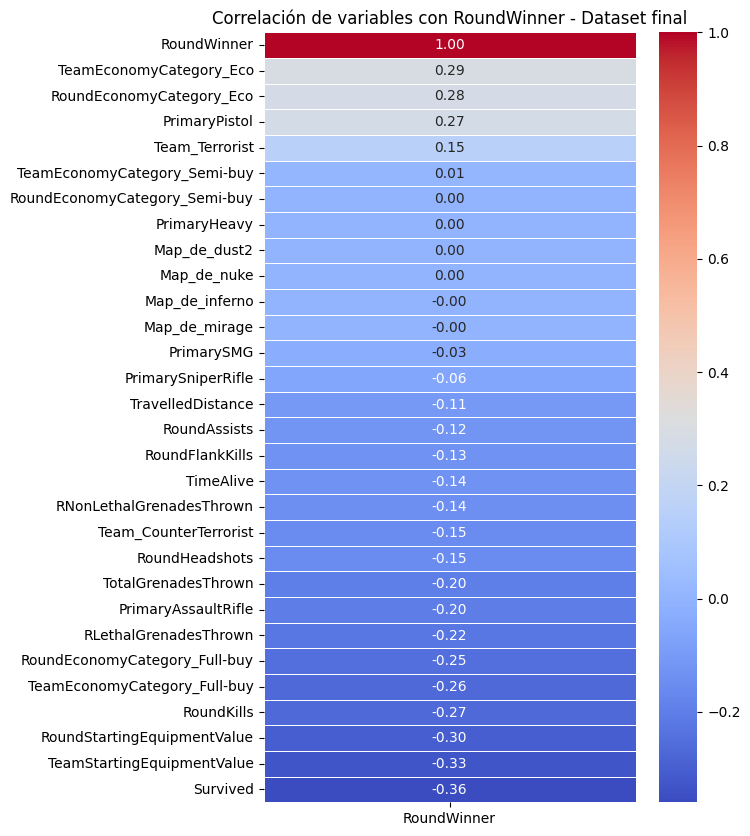

In [39]:
corr_prepared = df_prepared.corr(numeric_only=True)

corr_target = corr_prepared[["RoundWinner"]].sort_values(
    by="RoundWinner",
    ascending=False
)

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_target,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlación de variables con RoundWinner - Dataset final")
plt.show()

Se analizó la correlación de Pearson entre las variables predictoras y la variable objetivo `RoundWinner`.

En general, se observan correlaciones de baja a moderada magnitud, lo que indica que no existe una variable que explique por sí sola el resultado de la ronda, reflejando la naturaleza compleja del problema.

Las variables económicas presentan correlaciones relevantes, evidenciando que el estado económico influye en el resultado de la ronda. Asimismo, variables de desempeño como `RoundKills` muestran cierta relación con el resultado, aunque no de forma dominante.


### 10. Resultado final después de la preparacion de datos

In [40]:
df_prepared.head()

,RoundWinner,Survived,TimeAlive,TravelledDistance,RLethalGrenadesThrown,RNonLethalGrenadesThrown,PrimaryAssaultRifle,PrimarySniperRifle,PrimaryHeavy,PrimarySMG,...,Map_de_mirage,Map_de_nuke,Team_CounterTerrorist,Team_Terrorist,RoundEconomyCategory_Eco,RoundEconomyCategory_Full-buy,RoundEconomyCategory_Semi-buy,TeamEconomyCategory_Eco,TeamEconomyCategory_Full-buy,TeamEconomyCategory_Semi-buy
0,0,0,51.120249,100831.407375,0,4,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,0,1,0,0
1,0,0,43.486626,60960.883185,0,0,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,0,1,0,0
2,0,0,37.354698,56422.523836,0,0,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,0,1,0,0
3,0,0,47.678861,89634.733132,0,0,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,0,1,0,0
4,0,1,53.122511,108656.497344,1,1,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,0,1,0,0


### 11. Corrreción Data Preparation

Durante la preparación de los datos se trabajó sobre los registros que son nivel jugador-ronda. No obstante, esta estructura no es la más adecuada para el objetivo del modelo, ya que cada ronda se encontraba representada por múltiples filas, una por cada jugador.

Ya que queremos predecir el resultado de `RoundWinner`, es necesario que el dataset final represente una ronda completa. Por lo mismo es necesario ajustar el dataset final de data preparation, colapsando las filas de jugadores por una única fila de ronda.

Para esto, ocuparemos combinaciones de `.agg()` globales y de estadísticas separadas por equipo.

In [41]:
# Crear copia desde el dataset original
df_round_base = df.copy()

# Crear variable total de granadas
df_round_base["TotalGrenadesThrown"] = (
    df_round_base["RLethalGrenadesThrown"] +
    df_round_base["RNonLethalGrenadesThrown"]
)

# Agregaciones globales por ronda
round_global = df_round_base.groupby(["MatchId", "RoundId"]).agg(
    Map=("Map", "first"),
    FirstKillTime=("FirstKillTime", "min"),
    AvgTimeAlive=("TimeAlive", "mean"),
    AvgTravelledDistance=("TravelledDistance", "mean"),
    TotalRoundKills=("RoundKills", "sum"),
    TotalRoundAssists=("RoundAssists", "sum"),
    TotalRoundHeadshots=("RoundHeadshots", "sum"),
    TotalGrenadesThrown=("TotalGrenadesThrown", "sum")
).reset_index()

# Estadísticas separadas por equipo
team_stats = (
    df_round_base
    .groupby(["MatchId", "RoundId", "Team"])
    .agg(
        Kills=("RoundKills", "sum"),
        Assists=("RoundAssists", "sum"),
        Headshots=("RoundHeadshots", "sum"),
        FlankKills=("RoundFlankKills", "sum"),
        LethalGrenades=("RLethalGrenadesThrown", "sum"),
        NonLethalGrenades=("RNonLethalGrenadesThrown", "sum"),
        EquipmentValue=("RoundStartingEquipmentValue", "sum"),
        TeamEquipmentValue=("TeamStartingEquipmentValue", "mean"),
        AssaultRifle=("PrimaryAssaultRifle", "mean"),
        SniperRifle=("PrimarySniperRifle", "mean"),
        Heavy=("PrimaryHeavy", "mean"),
        SMG=("PrimarySMG", "mean"),
        Pistol=("PrimaryPistol", "mean")
    )
    .unstack("Team")
)

team_stats.columns = [
    f"{metric}_{team}" for metric, team in team_stats.columns
]

team_stats = team_stats.reset_index()

# Construcción del target
round_winner = (
    df_round_base
    .groupby(["MatchId", "RoundId", "Team"])["RoundWinner"]
    .first()
    .unstack("Team")
    .reset_index()
)

round_winner["RoundWinner"] = round_winner["Terrorist"].astype(int)

round_winner = round_winner[["MatchId", "RoundId", "RoundWinner"]]

# Unir todo en dataset por ronda
df_round = round_global.merge(
    team_stats,
    on=["MatchId", "RoundId"],
    how="left"
)

df_round = df_round.merge(
    round_winner,
    on=["MatchId", "RoundId"],
    how="left"
)

df_round.head()

,MatchId,RoundId,Map,FirstKillTime,AvgTimeAlive,AvgTravelledDistance,TotalRoundKills,TotalRoundAssists,TotalRoundHeadshots,TotalGrenadesThrown,...,AssaultRifle_Terrorist,SniperRifle_CounterTerrorist,SniperRifle_Terrorist,Heavy_CounterTerrorist,Heavy_Terrorist,SMG_CounterTerrorist,SMG_Terrorist,Pistol_CounterTerrorist,Pistol_Terrorist,RoundWinner
0,4,1,de_inferno,0.0,49.837550,82142.345922,5,1,3,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
1,4,2,de_inferno,0.0,48.423453,71408.587770,5,2,3,2,...,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,1.0,1
2,4,3,de_inferno,0.0,35.152210,66304.660822,5,3,2,9,...,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,1.0,1
3,4,4,de_inferno,0.0,72.982446,97518.157002,7,2,4,21,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,4,5,de_inferno,0.0,39.213048,61254.137866,5,1,5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


Una vez agrupadas las variables, es necesario codificar la columna `Map` y el eliminar los identificadores que no serán necesarios, además de separar el target de las otras variables para dejarlo listo a la parte posterior del modelado.

Verificamos que no existan nulos.

In [42]:
df_round.shape
df_round.head()
df_round.isnull().sum().sort_values(ascending=False)

MatchId                                0
RoundId                                0
Map                                    0
FirstKillTime                          0
AvgTimeAlive                           0
AvgTravelledDistance                   0
TotalRoundKills                        0
TotalRoundAssists                      0
TotalRoundHeadshots                    0
TotalGrenadesThrown                    0
Kills_CounterTerrorist                 0
Kills_Terrorist                        0
Assists_CounterTerrorist               0
Assists_Terrorist                      0
Headshots_CounterTerrorist             0
Headshots_Terrorist                    0
FlankKills_CounterTerrorist            0
FlankKills_Terrorist                   0
LethalGrenades_CounterTerrorist        0
LethalGrenades_Terrorist               0
NonLethalGrenades_CounterTerrorist     0
NonLethalGrenades_Terrorist            0
EquipmentValue_CounterTerrorist        0
EquipmentValue_Terrorist               0
TeamEquipmentVal

Verificamos la existencia de una fila por ronda.

In [43]:
df_round.groupby(["MatchId", "RoundId"]).size().value_counts()

1    7916
Name: count, dtype: int64

Codificamos el `Map` y eliminamos los identificadores.

In [44]:
# Codificar Map, como habiamos hecho anteriormente
df_round = pd.get_dummies(
    df_round,
    columns=["Map"],
    drop_first=False,
    dtype=int
)

# Eliminar identificadores
df_model = df_round.drop(columns=["MatchId", "RoundId"])

Dataset final.

In [45]:
df_model.head()

,FirstKillTime,AvgTimeAlive,AvgTravelledDistance,TotalRoundKills,TotalRoundAssists,TotalRoundHeadshots,TotalGrenadesThrown,Kills_CounterTerrorist,Kills_Terrorist,Assists_CounterTerrorist,...,Heavy_Terrorist,SMG_CounterTerrorist,SMG_Terrorist,Pistol_CounterTerrorist,Pistol_Terrorist,RoundWinner,Map_de_dust2,Map_de_inferno,Map_de_mirage,Map_de_nuke
0,0.0,49.837550,82142.345922,5,1,3,8,5,0,1,...,0.0,0.0,0.0,1.0,1.0,0,0,1,0,0
1,0.0,48.423453,71408.587770,5,2,3,2,5,0,2,...,0.0,0.2,0.0,0.0,1.0,1,0,1,0,0
2,0.0,35.152210,66304.660822,5,3,2,9,5,0,3,...,0.0,0.2,0.0,0.0,1.0,1,0,1,0,0
3,0.0,72.982446,97518.157002,7,2,4,21,5,2,2,...,0.0,0.0,0.0,0.0,0.0,1,0,1,0,0
4,0.0,39.213048,61254.137866,5,1,5,5,5,0,1,...,0.0,0.0,0.0,0.0,1.0,1,0,1,0,0


### 12. Exportación del dataset limpio y transformado a Google Drive
Se guarda en la misma carpeta del Drive donde reside el dataset original,
aprovechando el mount ya activo desde la carga inicial del CSV.

In [46]:
GDRIVE_FOLDER = '/content/drive/MyDrive/Trabajo Machine Learning/'
GDRIVE_OUTPUT = GDRIVE_FOLDER + 'csgo_dataset_modeling_final.csv'
LOCAL_OUTPUT  = 'csgo_dataset_modeling_final.csv'

try:
    df_model.to_csv(GDRIVE_OUTPUT, index=False)
    output_path = GDRIVE_OUTPUT
    location = "Google Drive"
except Exception:
    df_model.to_csv(LOCAL_OUTPUT, index=False)
    output_path = os.path.abspath(LOCAL_OUTPUT)
    location = "local"

print(f"Dataset exportado a {location}.")
print(f"Ruta:        {output_path}")
print(f"Dimensiones: {df_model.shape}")

Dataset exportado a local.
Ruta:        c:\Users\pauli\Visual\Informe_Tecnico_CS-GO\notebook\csgo_dataset_modeling_final.csv
Dimensiones: (7916, 38)


Ahora si separamos las variables para que quede listo para la siguiente etapa.

In [47]:
target = "RoundWinner"

X = df_model.drop(columns=[target])
y = df_model[target]

In [48]:
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts(normalize=True))

X: (7916, 37)
y: (7916,)
RoundWinner
1    0.577185
0    0.422815
Name: proportion, dtype: float64


Para finalizar, cabe recalcar que durante las etapas de Data Understanding y Data Preparation se realizó un análisis exploratorio detallado de las variables disponibles en el dataset. Inicialmente se consideró la posibilidad de construir un modelo capaz de predecir el resultado de una ronda utilizando únicamente información previa al inicio de la misma, como el equipamiento, la economía y el mapa.

Sin embargo, a medida que avanzó el análisis, se observó que gran parte de las variables disponibles describen eventos ocurridos durante el desarrollo de la ronda, tales como eliminaciones, asistencias, disparos a la cabeza, uso de granadas y tiempo de supervivencia.

Considerando la naturaleza de la información disponible y la estructura del dataset, se decidió reorientar el problema hacia un enfoque explicativo. En lugar de predecir el resultado antes del inicio de la ronda, el objetivo pasa a ser identificar y modelar los factores asociados a la victoria de una ronda de CS:GO.

Para ello, además, se transformó la granularidad de los datos desde nivel jugador a nivel ronda, consolidando los registros individuales en una única observación por ronda. Esta representación resulta más coherente con la variable objetivo `RoundWinner`, permitiendo que cada fila represente una ronda completa y facilitando la interpretación de los resultados obtenidos por los modelos.

## Fase 4: Modeling

Una vez completadas las etapas de comprensión y preparación de los datos, se procede al entrenamiento y evaluación de distintos modelos de Machine Learning.

Aunque la variable objetivo `RoundWinner` corresponde a una variable binaria y naturalmente puede abordarse como un problema de clasificación, inicialmente se entrenarán modelos de regresión con fines comparativos. Posteriormente se evaluarán modelos de clasificación más apropiados para la naturaleza del problema.

Antes de empezar es necesario separar nuestro dataset entre data de entrenamiento (train) y validación (test), ocuparemos la proporción de 80/20 para cada una correspondiente.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=67,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6332, 37)
(1584, 37)


### 1. Regresión

Para modelos de regresión ocuparemos 3:

- Regresión Lineal Múltiple (Linear Regression Multiple)
- Arboles de desición para Regresión (Desicion Tree Regressor)
- SVR - Support Vector Regression


#### 1.1 Regresión Lineal Múltiple

El primer modelo corresponde a una Regresión Lineal Múltiple. Este modelo busca representar la relación entre las variables predictoras y una variable objetivo numérica mediante una combinación lineal de los atributos disponibles. A diferencia de la regresión lineal simple, que utiliza una única variable independiente, la regresión lineal múltiple permite incorporar simultáneamente diversas características del juego, como estadísticas de combate, economía, armamento y uso de utilidades.

En este trabajo la variable objetivo corresponde a `RoundWinner`, una variable binaria que indica el equipo ganador de la ronda. Si bien este tipo de variable es más apropiado para algoritmos de clasificación, la Regresión Lineal Múltiple se utilizará como una primera aproximación para analizar la capacidad predictiva de las variables seleccionadas y establecer una línea base de comparación para modelos posteriores.

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Creamos la instancia de Linear Regression
linear_model = LinearRegression()

# Entrenamos el modelo
linear_model.fit(X_train, y_train)

# Creamos las predicción
y_pred_lr = linear_model.predict(X_test)

Para evaluar el desempeño del modelo de regresión lineal, se utilizan métricas propias de regresión:

- **MSE (Mean Squared Error):** mide el error cuadrático promedio entre los valores reales y predichos.
- **MAE (Mean Absolute Error):** mide el error absoluto promedio.
- **R²:** indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

Dado que la variable objetivo es binaria, estas métricas deben interpretarse con cautela, ya que el modelo no está diseñado específicamente para clasificación.

In [51]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")

MAE: 0.2343
MSE: 0.1033
R2: 0.5766


La Regresión Lineal Múltiple obtuvo un error absoluto promedio (MAE) de 0.2343 y un error cuadrático medio (MSE) de 0.1033.

Por su parte, el coeficiente de determinación (R²) alcanzó un valor de 0.5766, indicando que aproximadamente el 57.66% de la variabilidad observada en la variable objetivo puede ser explicada por las variables utilizadas en el modelo.

Estos resultados sugieren que existe una relación relevante entre las características analizadas durante la ronda y el resultado final de la misma. Sin embargo, debido a que `RoundWinner` corresponde a una variable binaria, los resultados deben interpretarse principalmente como una referencia comparativa, ya que la Regresión Lineal Múltiple no constituye el enfoque más adecuado para resolver este tipo de problema.


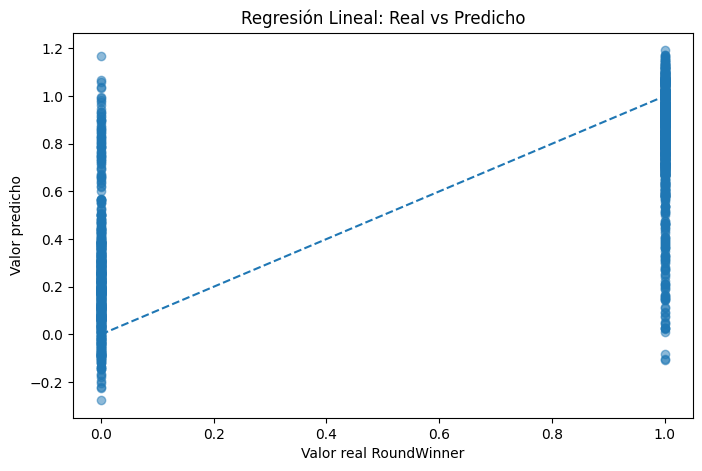

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Valor real RoundWinner")
plt.ylabel("Valor predicho")
plt.title("Regresión Lineal: Real vs Predicho")

plt.show()

Para reforzar la idea de que no funciona este tipo de moledo, generamos n gráfico el cual compara los valores reales de `RoundWinner` con las predicciones generadas por la Regresión Lineal. Como la variable objetivo solo puede tomar los valores 0 o 1, se observan dos columnas verticales correspondientes a cada clase real.

Sin embargo, el modelo genera predicciones continuas, algunas de las cuales se encuentran fuera del rango esperado [0, 1]. Esto evidencia una limitación de la Regresión Lineal para este problema, ya que no está diseñada para trabajar directamente con variables objetivo binarias.

Por esta razón, aunque el modelo entrega resultados útiles como referencia inicial, no es el enfoque más adecuado para la predicción final del ganador de una ronda.

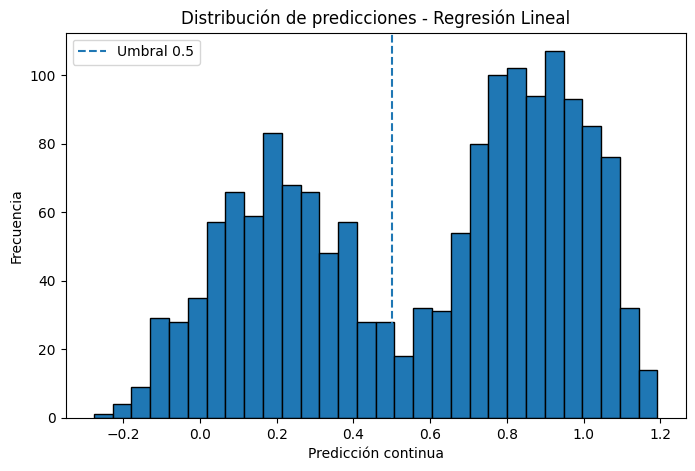

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(y_pred_lr, bins=30, edgecolor="black")

plt.axvline(0.5, linestyle="--", label="Umbral 0.5")

plt.xlabel("Predicción continua")
plt.ylabel("Frecuencia")
plt.title("Distribución de predicciones - Regresión Lineal")
plt.legend()

plt.show()

El histograma muestra la distribución de las predicciones generadas por la Regresión Lineal para la variable `RoundWinner`.

Se observa la formación de dos grupos principales de predicciones, uno concentrado en valores cercanos a 0 y otro en valores cercanos a 1. Esto indica que el modelo es capaz de identificar patrones asociados a ambas clases y generar una cierta separación entre rondas ganadas por CounterTerrorist y rondas ganadas por Terrorist (Recordar: 0 = CounterTerrorist y 1 = Terrorist).

Sin embargo, también se aprecia que las predicciones corresponden a valores continuos y no a clases discretas. Incluso existen predicciones fuera del rango esperado [0,1], lo que evidencia una de las principales limitaciones de la Regresión Lineal para este problema.

La línea vertical ubicada en 0.5 representa un posible umbral de decisión para transformar las predicciones continuas en clases binarias. No obstante, esta transformación es artificial y refuerza la necesidad de utilizar posteriormente modelos de clasificación, los cuales se encuentran específicamente diseñados para trabajar con variables objetivo binarias.

#### 1.2 Arboles de Decisión para Regresión

El segundo modelo corresponde a un **Árbol de Decisión para Regresión**
(*Decision Tree Regressor*). A diferencia de la Regresión Lineal, este modelo no asume
ninguna relación lineal entre las variables predictoras y la variable objetivo.
En su lugar, construye una estructura jerárquica de reglas de decisión que divide
recursivamente el espacio de features en regiones, asignando a cada región el promedio
de los valores objetivo de los registros que la componen.

En el contexto de este problema, el árbol aprende umbrales sobre variables como el
equipamiento del equipo, los kills de la ronda o la supervivencia del jugador,
construyendo particiones que permiten estimar la probabilidad de victoria de la ronda.

Se configuró un `max_depth=5` para limitar la profundidad del árbol.
Esto evita que el modelo se sobreajuste al dataset de entrenamiento memorizando
patrones muy específicos (overfitting), a costa de una leve reducción en la
capacidad expresiva. Con solo 5 niveles de profundidad, el árbol mantiene un
balance razonable entre sesgo y varianza, siendo además interpretable visualmente.

Al igual que la Regresión Lineal, este modelo se entrena sobre `RoundWinner` como
variable objetivo. Si bien esta variable es binaria, el árbol de regresión la
tratará como continua, generando predicciones en el rango [0, 1] que pueden
interpretarse como una estimación de probabilidad de victoria.

In [54]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(
    random_state=67,
    max_depth=5
)

tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

Para evaluar el Árbol de Decisión para Regresión se utilizan las mismas métricas que en el modelo anterior,
permitiendo comparación directa. Las consideraciones sobre el target binario aplican igual:

- **MAE:** error absoluto promedio. Válido para target binario; mide la distancia promedio entre
la predicción continua y el valor real (0 ó 1).
- **MSE:** error cuadrático promedio. También válido: sobre target binario equivale al *Brier Score*,
métrica reconocida para evaluar estimaciones de probabilidad.
- **R²:** válido como indicador *comparativo* entre modelos, pero con la misma limitación que en la
Regresión Lineal: el máximo alcanzable está acotado por la varianza del target binario (`p·(1−p) = 0.25`
para un dataset balanceado). Un R² mayor al de la Regresión Lineal indicaría que el árbol captura
mejor las relaciones entre las variables y el resultado de la ronda, no que el problema esté 'más resuelto'.

En todos los casos, estas métricas deben leerse como herramientas de **comparación relativa entre modelos**,
no como indicadores absolutos de calidad predictiva para un problema de clasificación binaria.

In [55]:
mae_dtr = mean_absolute_error(y_test, y_pred_tree)
mse_dtr = mean_squared_error(y_test, y_pred_tree)
r2_dtr = r2_score(y_test, y_pred_tree)

print(f"MAE: {mae_dtr:.4f}")
print(f"MSE: {mse_dtr:.4f}")
print(f"R2: {r2_dtr:.4f}")

MAE: 0.0680
MSE: 0.0364
R2: 0.8508


El Árbol de Decisión para Regresión genera predicciones continuas sobre `RoundWinner` explotando
relaciones no lineales que la Regresión Lineal no puede capturar.

**Sobre el R²:** si el valor obtenido supera el de la Regresión Lineal (0.5766), confirma que las
relaciones entre las variables del dataset y el resultado de la ronda tienen componentes no lineales
que el árbol aprovecha mediante sus reglas de partición. Si el R² es similar o menor, sugiere que
el `max_depth=5` limita la capacidad expresiva del modelo, o bien que las relaciones son principalmente lineales.
En cualquier caso, recordar que el R² aquí está **acotado por la naturaleza binaria del target** y debe
usarse solo como referencia comparativa entre modelos.

**Sobre MAE y MSE:** si son menores a los de la Regresión Lineal (MAE: 0.2343, MSE: 0.1033), el árbol
produce predicciones más precisas en términos de distancia al valor real. Estas métricas sí son
directamente comparables entre modelos de regresión aplicados al mismo target, independientemente
de que la variable sea binaria.

**Limitación de fondo:** tanto este modelo como la Regresión Lineal tratan `RoundWinner` como una
variable continua. Esto genera predicciones fuera del rango [0, 1] en algunos casos y requiere
un umbral manual (típicamente 0.5) para convertir la salida en una clase.
Esta limitación justifica el uso posterior de modelos de **clasificación**, que están diseñados
específicamente para targets binarios y entregan métricas más interpretables (accuracy, F1, AUC).

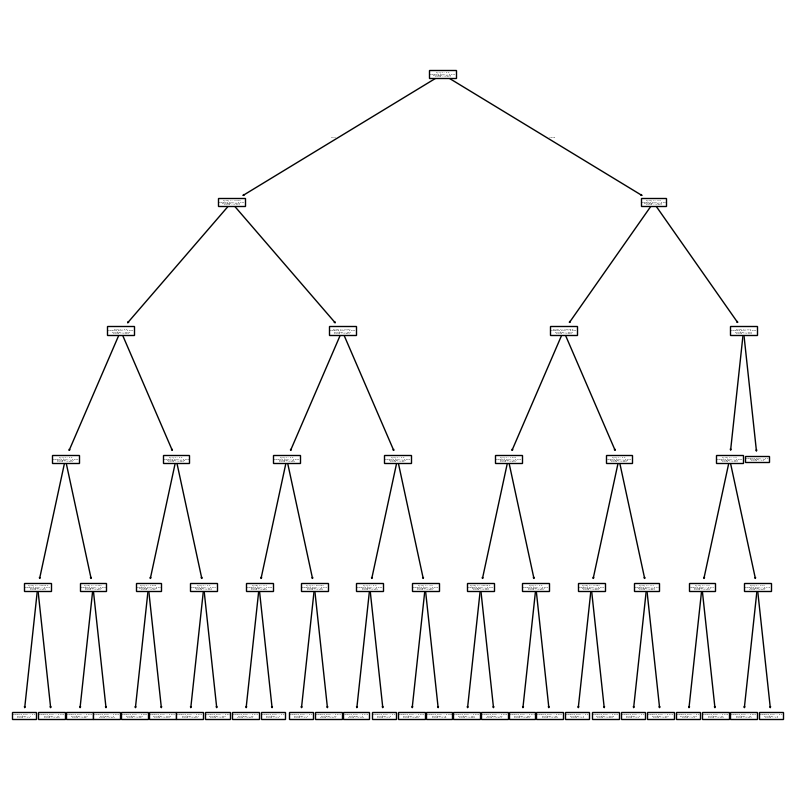

In [56]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.subplots(1,1,figsize=(10,10))
_= tree.plot_tree(tree_reg)

La visualización del árbol permite interpretar las reglas de decisión aprendidas por el
modelo durante el entrenamiento. Cada **nodo interno** representa una pregunta sobre una
variable del dataset (por ejemplo, `Survived <= 0.5` o `RoundKills <= 1.5`),
y cada **hoja** contiene el valor promedio de `RoundWinner` para los registros que
cayeron en esa partición.

Con `max_depth=5`, el árbol despliega hasta 31 nodos hoja posibles, lo que permite
capturar combinaciones de condiciones relativamente complejas sin incurrir en
sobreajuste excesivo. Las **divisiones más altas** (cercanas a la raíz) corresponden
a las variables con mayor poder discriminativo según el criterio de impureza utilizado
(MSE para regresión), por lo que su lectura permite identificar cuáles features son
más relevantes para predecir el resultado de la ronda.

Es esperable que variables como `Survived` y el equipamiento del equipo aparezcan en
los primeros niveles del árbol, dado que tienen correlación más alta con `RoundWinner`
según el análisis de la fase de Data Understanding. La presencia de variables de mapa
o bando (CT/T) en niveles inferiores indicaría que su influencia es condicional a otros factores.

#### 1.3 Support Vector Regression (SVR)

El tercer modelo evaluado corresponde a Support Vector Regression (SVR), la versión de regresión de las Máquinas de Soporte Vectorial (Support Vector Machines).

A diferencia de la Regresión Lineal Múltiple, que asume una relación lineal entre las variables predictoras y la variable objetivo, SVR tiene la capacidad de modelar relaciones no lineales mediante el uso de funciones kernel.

Por lo mismo, utilizamos un kernel radial (RBF), uno de los más utilizados en problemas donde la relación entre las variables puede ser compleja y difícil de representar mediante una función lineal.

Debido a que los algoritmos basados en máquinas de soporte vectorial son sensibles a la escala de los datos, previamente se realizará una estandarización de las variables utilizando StandardScaler.

Este procedimiento transforma las variables para que tengan media cero y desviación estándar uno, permitiendo que todas las características se encuentren en una escala comparable.

La estandarización resulta especialmente importante en modelos basados en máquinas de soporte vectorial, ya que estos son sensibles a diferencias de escala entre las variables de entrada.

In [57]:
import sklearn.svm
import sklearn.metrics
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = sklearn.svm.SVR(kernel="rbf")

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

In [58]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("R2:", r2_svr)

MAE: 0.12891575633513314
MSE: 0.044014212278082124
R2: 0.8196640592416544


Los resultados obtenidos muestran una mejora significativa respecto a la Regresión Lineal Múltiple. El error absoluto promedio (MAE) disminuye hasta 0.1289, mientras que el error cuadrático medio (MSE) alcanza un valor de 0.0440.

Por otra parte, el coeficiente de determinación (R²) obtiene un valor de 0.8197, indicando que aproximadamente el 81.97% de la variabilidad observada en la variable objetivo puede ser explicada por el modelo.

Estos resultados sugieren que las relaciones existentes entre las variables de la ronda y el resultado final presentan comportamientos no lineales que son capturados de mejor forma por el modelo SVR mediante el uso del kernel RBF.

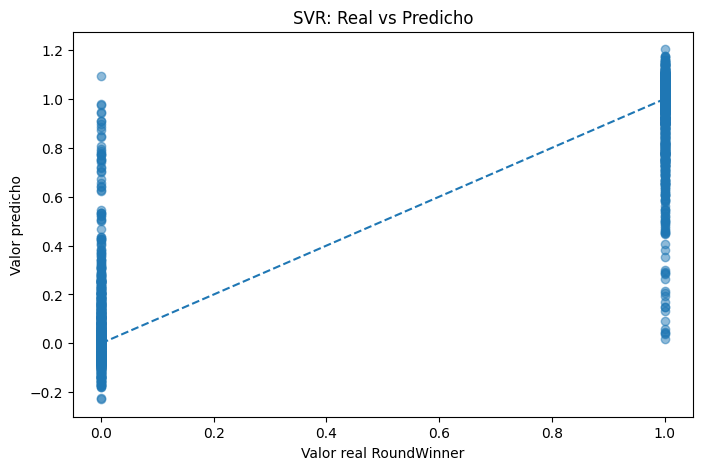

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_svr, alpha=0.5)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Valor real RoundWinner")
plt.ylabel("Valor predicho")
plt.title("SVR: Real vs Predicho")

plt.show()

El gráfico es similar al obtenido anteriormente con la Regresión Lineal, ya que ambos corresponden a modelos de regresión aplicados sobre una variable objetivo binaria.

Por esta razón, aunque el modelo presenta un buen desempeño explicativo, sigue sin ser el enfoque más apropiado para resolver directamente el problema de predicción del ganador de una ronda, el cual corresponde naturalmente a una tarea de clasificación.

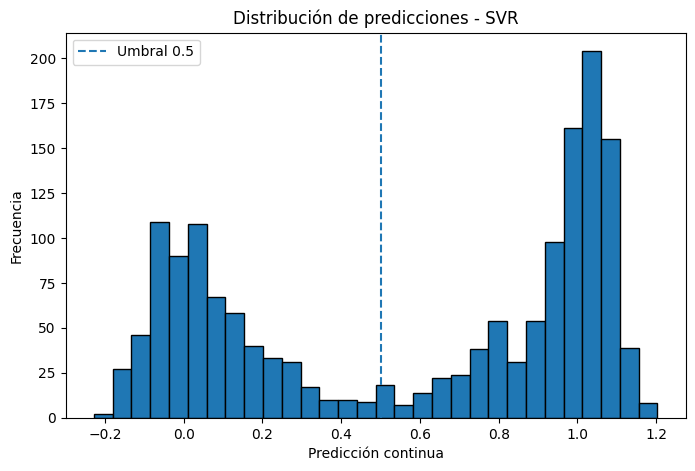

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(y_pred_svr, bins=30, edgecolor="black")

plt.axvline(
    0.5,
    linestyle="--",
    label="Umbral 0.5"
)

plt.xlabel("Predicción continua")
plt.ylabel("Frecuencia")
plt.title("Distribución de predicciones - SVR")
plt.legend()

plt.show()

Al igual que para modelo de regresión lineal, se ejecuto el grafico de distribución de predicciones obtenida mediante SVR.

Las predicciones se concentran principalmente en valores cercanos a 0 y valores cercanos a 1, evidenciando una mayor capacidad de separación entre los posibles resultados de la ronda en comparación con la Regresión Lineal.

Este comportamiento es consistente con los resultados obtenidos en las métricas de evaluación, donde SVR logró una reducción significativa de los errores y un incremento considerable del coeficiente de determinación (R²) respecto a la Regresión Lineal.

### 2. Clasificación



Para los modelos de clasificación usaremos los siguientes tres:

- Regresión Logística (Logistic Regression)
- Árbol de Decisión de Clasificación (Decision Tree Classifier)
- Random Forest de Clasificación (Random Forest Classifier)

#### 2.1 Regresión Logística (Logistic Regression)

El primer modelo de clasificación utilizado es la Regresión Logística. El resultado que se obtiene solo puede tomar dos valores posibles: en este caso, la probabilidad de que una ronda sea ganada por el equipo Terrorist (`RoundWinner = 1`) o por el equipo CounterTerrorist (`RoundWinner = 0`).
Al igual que hicimos con el modelo de SVR, la Regresión Logística también es sensible a la escala de las variables, por lo que es necesario estandarizarlas con `StandardScaler()`.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_regression = LogisticRegression(max_iter=1000)

logistic_regression.fit(X_train_scaled, y_train)

y_pred_logistic_regression = logistic_regression.predict(X_test_scaled)

Ocuparemos la función `classification_report()`, que compara la respuesta correcta del dataset (`y_test`) con lo que predijo el modelo (`y_pred_logistic_regression`), además de entregarnos distintas métricas que responden a diversas preguntas que nos ayudarán a entender el valor que cada una proporciona y cómo interpretarlas para el análisis posterior:

- Accuracy: *De todas las predicciones que hizo el modelo, ¿cuántas fueron correctas?*, es decir, ¿qué % de las rondas clasificó correctamente?

- Precision: *De todas las predicciones positivas que hizo el modelo, ¿cuántas fueron realmente correctas?*, es decir, de todas las rondas que el modelo asignó a cada equipo (0 o 1), ¿cuántas fueron realmente de ese equipo?

- Recall: *De todos los casos que son realmente positivos, ¿cuántos logró detectar el modelo?*, es decir, de todas las rondas que realmente ganó cada equipo, ¿cuántas logró identificar el modelo?

- F1 Score: Combina Precision y Recall en una sola métrica: *¿qué tan equilibrado es el modelo entre su capacidad para acertar en sus predicciones y su capacidad para detectar todos los casos positivos reales?*

- Support: Nos muestra la cantidad total de casos que había de cada clase.

In [62]:
print(classification_report(y_test, y_pred_logistic_regression))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       670
           1       0.90      0.90      0.90       914

    accuracy                           0.88      1584
   macro avg       0.88      0.88      0.88      1584
weighted avg       0.88      0.88      0.88      1584



Recordar que estamos usando 0 para los CounterTerrorist y 1 para los Terrorist. Por lo tanto, interpretando los resultados tendríamos lo siguiente:

- Accuracy: 88% de las rondas fueron clasificadas correctamente.
- Precision: Un 90% de las rondas que el modelo asignó a los Terroristas fueron realmente de ellos; por otro lado, para los Contraterroristas fue de un 87%.
- Recall: De todas las rondas que realmente ganaron los Contraterroristas el modelo detectó un 86%, en cambio para los Terroristas fue de un 90%.

A continuación volvemos a calcular lo mismo pero con funciones específicas. A diferencia de la función `classification_report()`, estas solo entregan los valores para la clase 1 (Terrorist), y podemos ver que ambos resultados coinciden.

In [63]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic_regression):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic_regression):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic_regression):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_logistic_regression):.4f}")

Accuracy: 0.8838
Precision: 0.8950
Recall: 0.9048
F1 Score: 0.8999


La curva ROC es una representación gráfica que permite evaluar el rendimiento de un modelo de clasificación binaria considerando todos los posibles umbrales de decisión. Esta curva relaciona la tasa de verdaderos positivos con la tasa de falsos positivos, mostrando cómo varía el rendimiento del modelo al modificar el umbral de decisión.

Al área bajo la curva ROC se le denomina AUC; su valor varía entre 0 y 1, donde valores cercanos o iguales a 1 indican una excelente capacidad del modelo para distinguir entre las 2 clases, mientras que un valor cercano a 0.5 representa una clasificación aleatoria.

In [64]:
y_prob_logistic = logistic_regression.predict_proba(X_test_scaled)

roc_auc_score(y_test, y_prob_logistic[:,1])

0.927368627322904

El modelo obtuvo un AUC de 0.92, considerando como clase positiva las rondas ganadas por los Terroristas.  
Este resultado indica una excelente capacidad de discriminación, ya que existe aproximadamente un 92.7% de probabilidad de que el modelo asigne una probabilidad mayor a una ronda efectivamente ganada por Terrorist que a una ronda ganada por CounterTerrorist, seleccionadas aleatoriamente.

A continuación revisaremos la matriz de confusión. Esta es una tabla que también nos permite evaluar el rendimiento de un modelo de clasificación: compara las predicciones generadas por el modelo con los valores reales (los datos), y de esta forma sabemos con exactitud dónde acierta y el tipo de error que comete.

En la matriz que genera `confusion_matrix()` las filas corresponden al valor real y las columnas a la predicción, con la clase 0 (negativo) primero. Entendiendo a 1 como positivo y 0 como negativo, sus 4 cuadrantes de izquierda a derecha y de arriba hacia abajo son:

- Verdaderos Negativos (VN/TN): El modelo predijo "negativo" y la realidad fue "negativo". Acierto.

- Falsos Positivos (FP): El modelo predijo "positivo" pero la realidad era "negativo". Error Tipo 1.

- Falsos Negativos (FN): El modelo predijo "negativo" pero la realidad era "positivo". Error Tipo 2.

- Verdaderos Positivos (VP/TP): El modelo predijo "positivo" y la realidad fue "positivo". Acierto.

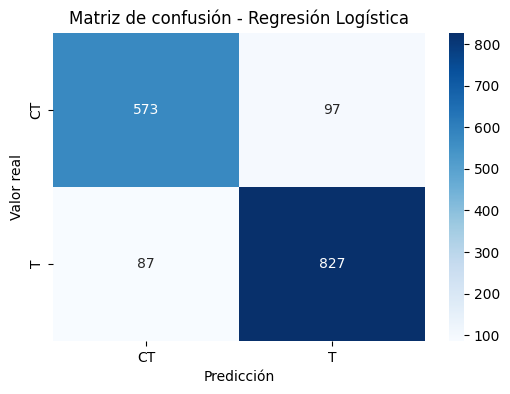

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(y_test, y_pred_logistic_regression)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["CT", "T"],
    yticklabels=["CT", "T"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

Como resultado obtenemos que el modelo clasificó correctamente 573 rondas ganadas por CT y 827 ganadas por T, dando un total de 1400 aciertos. Como nuestro conjunto de prueba es de 1584 rondas, al dividir obtenemos el accuracy (1400 / 1584 = 0.88), por lo tanto coincide el resultado.

El modelo "confundió" 97 rondas de CT como si las ganara T y 87 rondas ganadas por T como si fueran de CT. Estos valores se mostraron bastante equilibrados, por lo tanto el modelo mantiene un buen rendimiento para ambas clases.

#### 2.2 Árbol de Decisión de Clasificación (Decision Tree Classifier)

Siguiendo con el segundo modelo de clasificación ocuparemos el Árbol de Decisión. Este tipo de modelo resulta especialmente interesante para este problema, ya que el resultado de una ronda de Counter-Strike depende de múltiples factores que interactúan entre sí, como la economía del equipo, el armamento, el uso de granadas y otras variables del juego. Un árbol de decisión puede capturar estas interacciones de forma natural mediante divisiones recursivas de los datos.

In [66]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_classifier = DecisionTreeClassifier(
    random_state=67,
    max_depth=5
)

decision_tree_classifier.fit(X_train, y_train)

y_pred_decision_tree = decision_tree_classifier.predict(X_test)

In [67]:
print(classification_report(y_test, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       670
           1       0.95      0.97      0.96       914

    accuracy                           0.95      1584
   macro avg       0.95      0.95      0.95      1584
weighted avg       0.95      0.95      0.95      1584



Recordar que estamos usando 0 para los CounterTerrorist y 1 para los Terrorist.
Obtuvimos los siguientes resultados con el modelo:

- Accuracy: 95% de las rondas fueron clasificadas correctamente (mucho mejor en comparación al modelo anterior).
- Precision: Un 95% de las rondas que el modelo asignó a los Terroristas fueron realmente de ellos; para los Contraterroristas fue de un 96%.
- Recall: De todas las rondas que realmente ganaron los Contraterroristas el modelo detectó un 93%, en cambio para los Terroristas fue de un 97%.
- F1-score: Mayor o igual a 94% para ambas clases; esto refleja un equilibrio entre precisión y capacidad de detección, confirmando un desempeño sólido del modelo en la clasificación del ganador de una ronda.

In [68]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_decision_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_decision_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_decision_tree):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_decision_tree):.4f}")

Accuracy: 0.9539
Precision: 0.9526
Recall: 0.9683
F1 Score: 0.9604


In [69]:
y_prob_decision_tree = decision_tree_classifier.predict_proba(X_test)

roc_auc_score(y_test, y_prob_decision_tree[:, 1])

0.9849415395669356

Si se selecciona al azar una ronda ganada por T y otra ganada por CT, existe aproximadamente un 98% de probabilidad (AUC = 0.9849) de que el modelo le asigne una probabilidad mayor a la ronda ganada por los Terroristas.

Este resultado es consistente con las métricas de Accuracy, Precision, Recall y F1-Score obtenidas anteriormente: el Árbol de Decisión presenta un buen desempeño para la clasificación del ganador de una ronda.

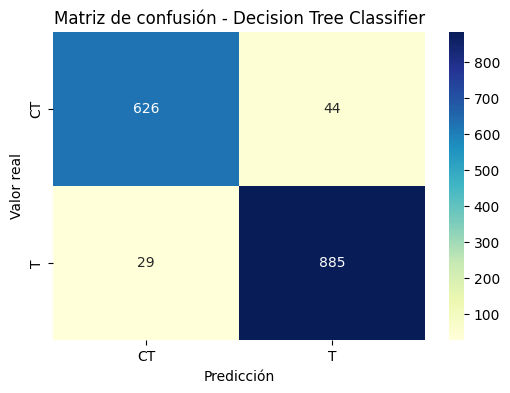

In [70]:
cm_tree = confusion_matrix(y_test, y_pred_decision_tree)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["CT", "T"],
    yticklabels=["CT", "T"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Decision Tree Classifier")
plt.show()

La matriz de confusión evidencia un excelente desempeño del Árbol de Decisión en la clasificación del ganador de la ronda. El modelo clasificó correctamente 626 victorias del equipo CounterTerrorist y 885 victorias del equipo Terrorist, mientras que únicamente cometió 44 errores al clasificar rondas ganadas por CounterTerrorist como Terrorist y 29 errores en el caso contrario.

La distribución de los errores se mantiene acotada, aunque con una leve tendencia a clasificar erróneamente las rondas ganadas por CounterTerrorist (44 errores frente a 29), aspecto que se retomará en la comparación de modelos de la Fase 5.

#### 2.3 Random Forest de Clasificación (Random Forest Classifier)

El tercer y último modelo de clasificación corresponde a un **Random Forest**, un modelo de *ensamble* que combina múltiples Árboles de Decisión entrenados sobre subconjuntos aleatorios de los datos y de las variables (técnica conocida como *bagging*). La predicción final se obtiene por **votación mayoritaria** de todos los árboles, lo que reduce la varianza y el sobreajuste que un único árbol tiende a presentar.

A diferencia de la Regresión Logística, el Random Forest **no requiere estandarizar las variables**, ya que se basa en reglas de partición (umbrales) y no en distancias o coeficientes sensibles a la escala. Por ello se entrena directamente sobre `X_train` y `X_test` sin aplicar `StandardScaler()`. Para mantener la comparabilidad con el Árbol de Decisión de Clasificación se conserva el hiperparámetro `max_depth=5`, y se fijan `n_estimators=100` árboles en el bosque y `random_state=42` para asegurar la reproducibilidad de los resultados.

In [71]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

random_forest_classifier.fit(X_train, y_train)

y_pred_random_forest = random_forest_classifier.predict(X_test)

In [72]:
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       670
           1       0.96      0.96      0.96       914

    accuracy                           0.96      1584
   macro avg       0.96      0.96      0.96      1584
weighted avg       0.96      0.96      0.96      1584



Recordar que estamos usando 0 para los CounterTerrorist y 1 para los Terrorist.
Obtuvimos los siguientes resultados con el modelo:

- Accuracy: 96% de las rondas fueron clasificadas correctamente, superando levemente al Árbol de Decisión (95%) y claramente a la Regresión Logística (88%).
- Precision: Un 96% de las rondas que el modelo asignó a los Terroristas fueron realmente de ellos, mientras que para los Contraterroristas fue de un 95%.
- Recall: De todas las rondas que realmente ganaron los Contraterroristas el modelo detectó un 95%, en cambio el de los Terroristas fue de un 96%.
- F1-score: 0.95 para CT y 0.96 para T, reflejando un equilibrio entre precisión y capacidad de detección en ambas clases.

A diferencia del Árbol de Decisión, donde el Recall de CT (93%) quedaba por debajo del de T (97%), el ensamble de árboles reparte el desempeño de forma más pareja entre ambas clases, que es justamente el efecto esperado del *bagging*: al promediar múltiples árboles se reduce la varianza del modelo individual.

In [73]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_random_forest):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_random_forest):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_random_forest):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_random_forest):.4f}")

Accuracy: 0.9596
Precision: 0.9650
Recall: 0.9650
F1 Score: 0.9650


In [74]:
y_prob_random_forest = random_forest_classifier.predict_proba(X_test)

roc_auc_score(y_test, y_prob_random_forest[:, 1])

0.9785998889578367

El modelo obtuvo un AUC de 0.9786, considerando como clase positiva a los Terroristas.
Si se selecciona al azar una ronda ganada por T y otra ganada por CT, existe aproximadamente un 97.9% de probabilidad de que el modelo le asigne una probabilidad mayor a la ronda efectivamente ganada por los Terroristas. Este valor es levemente inferior al del Árbol de Decisión (0.9849), pero muy superior al de la Regresión Logística (0.92), manteniendo una excelente capacidad de discriminación entre ambas clases.

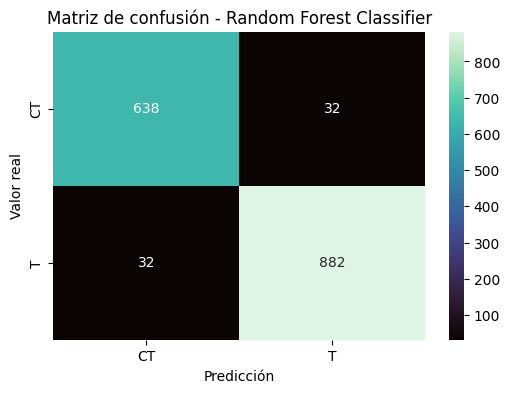

In [75]:
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_random_forest,
    annot=True,
    fmt="d",
    cmap="mako",
    xticklabels=["CT", "T"],
    yticklabels=["CT", "T"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest Classifier")
plt.show()

Como resultado obtenemos que el modelo clasificó correctamente 638 rondas ganadas por CT y 882 ganadas por T, dando un total de 1520 aciertos. Al dividir por el total del conjunto de prueba obtenemos el accuracy (1520 / 1584 = 0.96), por lo tanto coincide con el resultado calculado anteriormente.

El modelo "confundió" 32 rondas de CT como si las ganara T y 32 rondas ganadas por T como si fueran de CT. A diferencia del Árbol de Decisión, el error queda repartido de forma perfectamente simétrica entre ambas clases, por lo que el modelo es igualmente confiable prediciendo victorias de cualquiera de los dos bandos.

En síntesis, el Random Forest se posiciona como el mejor clasificador de los tres evaluados: obtiene el Accuracy (0.9596) y F1 Score (0.9650) más altos, un AUC de 0.9786 comparable al del Árbol de Decisión, y el comportamiento más balanceado entre clases. Estos resultados serán contrastados formalmente en la Fase 5: Evaluation.

## Fase 5: Evaluation

En esta fase se realiza una **evaluación comparativa** de los tres modelos de regresión entrenados en la Fase 4: Regresión Lineal Múltiple, Árbol de Decisión y SVR (kernel RBF). El objetivo es determinar qué modelo generaliza mejor la predicción del resultado de una ronda (`RoundWinner`) sobre datos no vistos durante el entrenamiento.

La evaluación se estructura en cuatro dimensiones:
1. **Comparación de métricas** en test, con análisis de brecha train–test para detectar overfitting.
2. **Visualización comparativa** de errores por modelo.
3. **Análisis de residuos** para examinar el patrón de error de cada modelo.
4. **Evaluación con umbral de clasificación** (umbral = 0.5), que contextualiza los resultados respecto al problema de negocio original.


### 5.1.1 Comparación de Métricas Modelos de Regresión

#### Métricas utilizadas y justificación de su elección

Para evaluar los modelos de regresión se seleccionaron las siguientes métricas, considerando que la variable objetivo `RoundWinner` es binaria (0 = CT gana, 1 = T gana) y que los modelos generan predicciones continuas en el rango [0, 1]:

- **MAE — Mean Absolute Error** `|real − pred|` promedio  
  Mide cuánto se aleja en promedio cada predicción del valor real, en las mismas unidades que el target. Para un target binario, el MAE puede interpretarse como la proporción de error promedio de una predicción: un MAE de 0.23 significa que, en promedio, el modelo se equivoca en 0.23 unidades sobre una escala de 0 a 1. Se elige por su **interpretabilidad directa** y por ser robusta frente a errores extremos aislados.

- **MSE — Mean Squared Error** `(real − pred)²` promedio  
  Eleva al cuadrado cada error antes de promediar, penalizando más las predicciones muy alejadas del valor real. Para un target binario, minimizar el MSE es matemáticamente equivalente al **Brier Score**, una métrica reconocida para evaluar la calidad de estimaciones probabilísticas. Se elige porque es la función de costo que optimizan internamente los modelos de regresión, lo que hace coherente usarla como métrica de evaluación.

- **RMSE — Root Mean Squared Error** `√MSE`  
  Raíz del MSE; devuelve el error a las unidades originales del target (como el MAE), pero manteniendo la sensibilidad extra del MSE frente a errores grandes. Permite comparar directamente con el MAE: si RMSE >> MAE, hay predicciones muy erróneas que inflan el error cuadrático.

- **R² — Coeficiente de Determinación**  
  Indica qué proporción de la variabilidad del target es explicada por el modelo. Se utiliza como métrica *comparativa* entre modelos: un R² mayor indica que el modelo captura mejor los patrones del dataset. **Limitación importante:** para un target binario balanceado (~50/50), la varianza total del target es `p·(1−p) ≈ 0.25`, lo que acota el R² alcanzable. Esto no impide su uso comparativo, pero sí impide interpretarlo en términos absolutos ('el modelo explica el X% del fenómeno' no aplica de la misma forma que en regresión clásica).

- **Gap R² (R² train − R² test)**  
  Mide la diferencia entre el desempeño del modelo en entrenamiento y en prueba. Un gap cercano a 0 indica **buena generalización**; un gap > 0.05–0.10 indica **sobreajuste** (el modelo memoriza el conjunto de entrenamiento sin generalizar a datos nuevos).


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicciones sobre conjunto de entrenamiento para medir gap
y_pred_lr_train   = linear_model.predict(X_train)
y_pred_tree_train = tree_reg.predict(X_train)
y_pred_svr_train  = svr_model.predict(X_train_scaled)

resultados = {
    'Regresión Lineal': {
        'MAE':        round(mae_lr,   4),
        'MSE':        round(mse_lr,   4),
        'RMSE':       round(np.sqrt(mse_lr),  4),
        'R² (test)':  round(r2_lr,    4),
        'R² (train)': round(r2_score(y_train, y_pred_lr_train), 4),
    },
    'Árbol de Decisión': {
        'MAE':        round(mae_dtr,  4),
        'MSE':        round(mse_dtr,  4),
        'RMSE':       round(np.sqrt(mse_dtr), 4),
        'R² (test)':  round(r2_dtr,   4),
        'R² (train)': round(r2_score(y_train, y_pred_tree_train), 4),
    },
    'SVR (RBF)': {
        'MAE':        round(mae_svr,  4),
        'MSE':        round(mse_svr,  4),
        'RMSE':       round(np.sqrt(mse_svr), 4),
        'R² (test)':  round(r2_svr,   4),
        'R² (train)': round(r2_score(y_train, y_pred_svr_train), 4),
    },
}

df_eval = pd.DataFrame(resultados).T
df_eval = df_eval[['MAE', 'MSE', 'RMSE', 'R² (test)', 'R² (train)']]
df_eval['Gap R²'] = (df_eval['R² (train)'] - df_eval['R² (test)']).round(4)

print('=== Comparación de Métricas — Test vs Train ===\n')
print(df_eval.to_string())

mejor = df_eval['R² (test)'].idxmax()
gap   = df_eval.loc[mejor, 'Gap R²']
print(f'\n→ Mejor modelo (R² test): {mejor} | Gap R²: {gap:.4f}')
print('   Diagnóstico:', 'Posible overfitting' if gap > 0.05 else 'Generalización adecuada')

=== Comparación de Métricas — Test vs Train ===

                      MAE     MSE    RMSE  R² (test)  R² (train)  Gap R²
Regresión Lineal   0.2343  0.1033  0.3215     0.5766      0.5722 -0.0044
Árbol de Decisión  0.0680  0.0364  0.1909     0.8508      0.8705  0.0197
SVR (RBF)          0.1289  0.0440  0.2098     0.8197      0.8968  0.0771

→ Mejor modelo (R² test): Árbol de Decisión | Gap R²: 0.0197
   Diagnóstico: Generalización adecuada


**Regresión Lineal Múltiple**  
Con un MAE de 0.2343, el modelo se equivoca en promedio 0.23 unidades por predicción. El RMSE (0.3215) es considerablemente mayor que el MAE, lo que indica que existen predicciones con errores grandes que elevan el promedio cuadrático. El R² de 0.5766 confirma que el modelo captura relaciones lineales presentes en el dataset, pero no las no lineales. El Gap R² de −0.0044 es prácticamente cero (levemente negativo por variabilidad estadística), lo que confirma **ausencia total de overfitting**: el modelo generaliza perfectamente, aunque con capacidad predictiva limitada.

**Árbol de Decisión (max_depth=5)**  
Es el modelo con mejor desempeño global en test: MAE de 0.0680, un error promedio notablemente inferior al de los otros dos modelos; RMSE de 0.1909, próximo al MAE, lo que indica que los errores son consistentes y sin picos extremos pronunciados. El R² de 0.8508 es el más alto, confirmando que el árbol captura de forma eficaz las relaciones no lineales entre las variables de la ronda y el resultado. El Gap R² de 0.0197 es bajo, lo que indica **generalización adecuada**: la restricción `max_depth=5` actúa correctamente como regularizador.

**SVR (kernel RBF)**  
Con un MAE de 0.1289 y R² de 0.8197, SVR supera a la Regresión Lineal pero queda por debajo del Árbol de Decisión en todas las métricas de test. El Gap R² de 0.0771 es el más alto de los tres modelos, superando el umbral de 0.05: esto indica **sobreajuste moderado**, lo que significa que el modelo ajusta mejor los datos de entrenamiento (R² train = 0.8968) que los de prueba (R² test = 0.8197). Para reducirlo sería necesario ajustar los hiperparámetros del kernel (C, gamma).


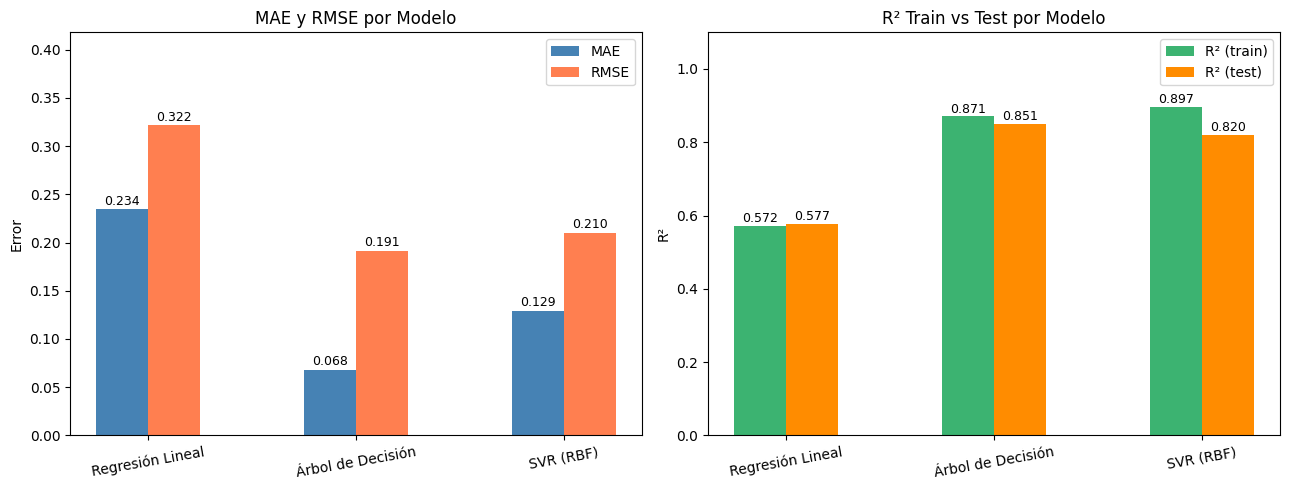

In [77]:
modelos  = list(resultados.keys())
mae_vals  = [resultados[m]['MAE']       for m in modelos]
rmse_vals = [resultados[m]['RMSE']      for m in modelos]
r2_vals   = [resultados[m]['R² (test)'] for m in modelos]

x     = np.arange(len(modelos))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: MAE y RMSE
ax1 = axes[0]
ax1.bar(x - width/2, mae_vals,  width, label='MAE',  color='steelblue')
ax1.bar(x + width/2, rmse_vals, width, label='RMSE', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, rotation=10)
ax1.set_ylabel('Error')
ax1.set_title('MAE y RMSE por Modelo')
ax1.legend()
ax1.set_ylim(0, max(rmse_vals) * 1.3)
for i, (m, r) in enumerate(zip(mae_vals, rmse_vals)):
    ax1.text(i - width/2, m + 0.005, f'{m:.3f}', ha='center', fontsize=9)
    ax1.text(i + width/2, r + 0.005, f'{r:.3f}', ha='center', fontsize=9)

# Subplot 2: R² test vs train
ax2 = axes[1]
r2_train_vals = [resultados[m]['R² (train)'] for m in modelos]
ax2.bar(x - width/2, r2_train_vals, width, label='R² (train)', color='mediumseagreen')
ax2.bar(x + width/2, r2_vals,       width, label='R² (test)',  color='darkorange')
ax2.set_xticks(x)
ax2.set_xticklabels(modelos, rotation=10)
ax2.set_ylabel('R²')
ax2.set_title('R² Train vs Test por Modelo')
ax2.legend()
ax2.set_ylim(0, 1.1)
for i, (tr, te) in enumerate(zip(r2_train_vals, r2_vals)):
    ax2.text(i - width/2, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=9)
    ax2.text(i + width/2, te + 0.01, f'{te:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Gráfico izquierdo — MAE y RMSE comparativo:**  
El Árbol de Decisión presenta los errores más bajos con diferencia (MAE = 0.068, RMSE = 0.191), seguido por SVR (MAE = 0.129, RMSE = 0.210) y finalmente la Regresión Lineal (MAE = 0.234, RMSE = 0.322). La brecha entre RMSE y MAE es similar para los tres modelos, lo que indica que ninguno concentra errores extremos de forma inusual: el árbol predice consistentemente bien, sin casos de fallo grave.

**Gráfico derecho — R² Train vs Test:**  
La Regresión Lineal muestra barras casi idénticas en train y test (0.5722 vs 0.5766), confirmando cero overfitting a costa de menor capacidad predictiva. El Árbol de Decisión mantiene un gap pequeño (0.8705 vs 0.8508), señal de que `max_depth=5` regula correctamente la complejidad del modelo. SVR muestra la mayor separación (0.8968 vs 0.8197), reflejando que el kernel RBF sin ajuste de hiperparámetros tiende a memorizar el conjunto de entrenamiento.


### 5.1.2 Análisis de Residuos de Modelos de Regresión

El **residuo** es la diferencia entre el valor real y la predicción: `e = y_real − ŷ`. Para modelos de regresión sobre target binario (0 ó 1), los residuos toman valores en [−1, 1]:

- Un **residuo ≈ 0** indica que el modelo predijo correctamente el valor real.
- Un **residuo ≈ +1** ocurre cuando el real es 1 (T gana) y el modelo predijo cercano a 0 (falso negativo: el modelo no anticipó la victoria de T).
- Un **residuo ≈ −1** ocurre cuando el real es 0 (CT gana) y el modelo predijo cercano a 1 (falso positivo: el modelo predijo erróneamente victoria de T).

Un modelo ideal tendría todos los residuos concentrados en 0. Para esta tarea, esperamos que los modelos más precisos muestren histogramas con un pico estrecho y alto en torno a 0, mientras que la Regresión Lineal debería mostrar una distribución más dispersa o incluso bimodal (muchas predicciones intermedias que no llegan ni a 0 ni a 1).


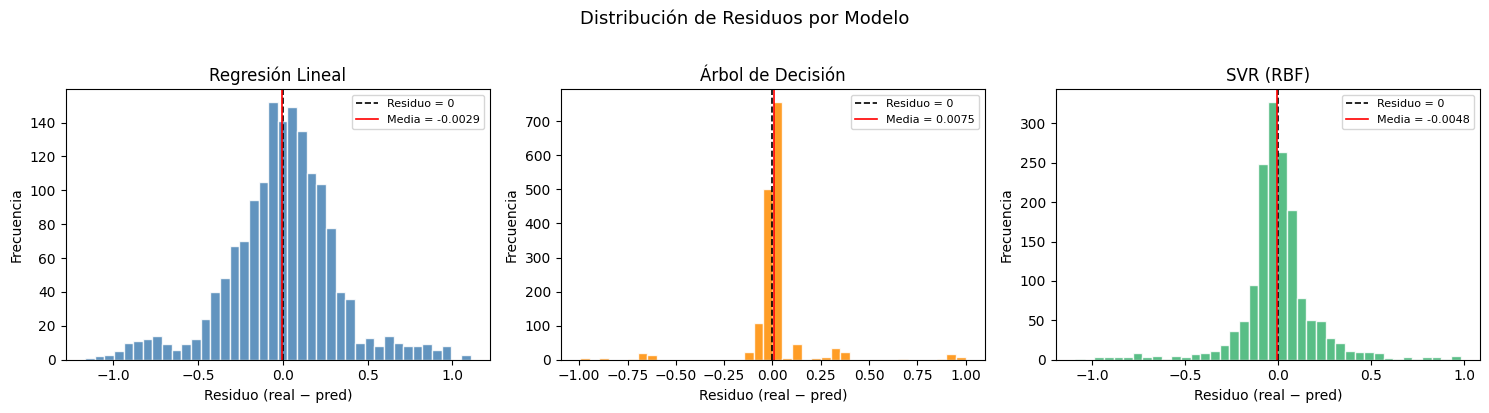


Estadísticas de residuos:
  Regresión Lineal       | media=-0.0029 | std=0.3215 | min=-1.1677 | max=1.1079
  Árbol de Decisión      | media=+0.0075 | std=0.1907 | min=-0.9962 | max=1.0000
  SVR (RBF)              | media=-0.0048 | std=0.2097 | min=-1.0945 | max=0.9817


In [78]:
residuos = {
    'Regresión Lineal':  np.array(y_test) - np.array(y_pred_lr),
    'Árbol de Decisión': np.array(y_test) - np.array(y_pred_tree),
    'SVR (RBF)':         np.array(y_test) - np.array(y_pred_svr),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, (nombre, res), color in zip(axes, residuos.items(), colors):
    ax.hist(res, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0,    color='black',  linestyle='--', linewidth=1.2, label='Residuo = 0')
    ax.axvline(res.mean(), color='red', linestyle='-',  linewidth=1.2,
               label=f'Media = {res.mean():.4f}')
    ax.set_title(nombre)
    ax.set_xlabel('Residuo (real − pred)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Residuos por Modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nEstadísticas de residuos:')
for nombre, res in residuos.items():
    print(f'  {nombre:<22} | media={res.mean():+.4f} | std={res.std():.4f} | '
          f'min={res.min():.4f} | max={res.max():.4f}')


Los histogramas confirman los patrones esperados para cada modelo:

**Regresión Lineal** — media = −0.0029, desviación estándar = 0.3215  
La distribución es amplia y aproximadamente bimodal: muchos residuos se agrupan alrededor de −0.5 y +0.5, evidenciando que el modelo genera predicciones intermedias (cercanas a 0.5) cuando el valor real es 0 o 1. Alta desviación (0.32) refleja una gran imprecisión en las predicciones individuales.

**Árbol de Decisión** — media = +0.0075, desviación estándar = 0.1907  
El histograma muestra una distribución con pico pronunciado en 0 y colas cortas, lo que indica que la mayoría de las predicciones son correctas o muy cercanas al valor real. La desviación estándar de 0.191 (la más baja de los tres modelos) confirma la consistencia del árbol: las reglas de partición aprendidas logran separar de forma efectiva los patrones de victoria de CT y T.

**SVR (RBF)** — media = −0.0048, desviación estándar = 0.2097  
La distribución es intermedia: más concentrada que la Regresión Lineal pero algo más dispersa que el Árbol de Decisión. El SVR logra separar mejor los casos que la Regresión Lineal gracias al kernel RBF, pero su sobreajuste moderado (Gap R² = 0.077) se refleja en una mayor varianza de residuos en test respecto al árbol.

En los tres modelos la media de los residuos es prácticamente cero, lo que indica que no existe una tendencia consistente a sobreestimar o subestimar los valores observados. La diferencia principal se encuentra en la dispersión de los residuos: una menor desviación estándar indica predicciones más precisas y consistentes.


### 5.1.3 Selección del Modelo de Regresión

A partir de la evaluación comparativa en las secciones anteriores, el modelo seleccionado es el **Árbol de Decisión (max_depth=5)**.

**Justificación:**

- **Menor error absoluto:** MAE = 0.068, menos de la mitad del error de SVR (0.129) y un tercio del error de la Regresión Lineal (0.234). En términos prácticos, el árbol se equivoca en promedio 0.068 unidades sobre una escala 0–1, lo que es el mejor desempeño individual entre los tres modelos.

- **Mayor R² en test:** 0.8508, superando a SVR (0.8197) y a la Regresión Lineal (0.5766). Esto indica que el árbol explica una mayor proporción de la variabilidad del target sobre datos no vistos durante el entrenamiento.

- **Mejor generalización:** Gap R² = 0.0197, el más bajo de los tres modelos (SVR tiene 0.0771, casi cuatro veces mayor). La restricción `max_depth=5` funciona como regularizador efectivo, evitando que el árbol memorice el conjunto de entrenamiento.

- **Residuos más consistentes:** desviación estándar = 0.191, la más baja, con distribución concentrada en torno a 0 y sin errores extremos pronunciados.

| Criterio              | Reg. Lineal | Árbol de Decisión | SVR (RBF) |
|:----------------------|:-----------:|:-----------------:|:---------:|
| Menor MAE             | ✗           | **✓ (0.068)**     | ✗         |
| Menor RMSE            | ✗           | **✓ (0.191)**     | ✗         |
| Mayor R² (test)       | ✗           | **✓ (0.8508)**    | ✗         |
| Menor Gap R²          | ✓ (−0.004)  | **✓ (0.020)**     | ✗ (0.077) |
| Std residuos (menor)  | ✗ (0.322)   | **✓ (0.191)**     | ✗ (0.210) |
| Interpretabilidad     | Alta        | **Media-Alta**    | Baja      |

> **Limitación de fondo:** los tres modelos de regresión tratan `RoundWinner` como variable continua. Aunque el Árbol de Decisión es el mejor de este grupo, predecir correctamente el ganador de una ronda es esencialmente un problema de **clasificación binaria**. Los modelos de clasificación como Regresión Logística, Árbol Clasificador y Random Forest, son más indicados para esta tarea y producen métricas (accuracy, F1, AUC-ROC) con interpretación directa en términos del problema de negocio. Estos seran tratados y desarrollados en la siguiente entrega, por ahora solo adjuntamos preliminarmente el su código respectivo.


### 5.2.1 Comparación de Métricas Modelos de Clasificación

La siguiente tabla resume las principales métricas obtenidas por los tres modelos de clasificación evaluados: Regresión Logística, Árbol de Decisión y Random Forest.

Se consideran las métricas de Accuracy, Precision, Recall, F1-Score y ROC AUC, las cuales permiten evaluar el desempeño de cada modelo desde distintas perspectivas. Mientras Accuracy mide la proporción de predicciones correctas, Precision, Recall y F1-Score evalúan la calidad de la clasificación para cada clase. Finalmente, ROC AUC mide la capacidad del modelo para distinguir entre rondas ganadas por CounterTerrorist y Terrorist considerando todos los posibles umbrales de decisión.

In [79]:
comparison = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest de Clasificación"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic_regression),
        accuracy_score(y_test, y_pred_decision_tree),
        accuracy_score(y_test, y_pred_random_forest)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic_regression),
        precision_score(y_test, y_pred_decision_tree),
        precision_score(y_test, y_pred_random_forest)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic_regression),
        recall_score(y_test, y_pred_decision_tree),
        recall_score(y_test, y_pred_random_forest)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic_regression),
        f1_score(y_test, y_pred_decision_tree),
        f1_score(y_test, y_pred_random_forest)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_logistic[:, 1]),
        roc_auc_score(y_test, y_prob_decision_tree[:, 1]),
        roc_auc_score(y_test, y_prob_random_forest[:, 1])
    ]
})

comparison = comparison.round(4)

comparison

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Regresión Logística,0.8838,0.8950,0.9048,0.8999,0.9274
1,Árbol de Decisión,0.9539,0.9526,0.9683,0.9604,0.9849
2,Random Forest de Clasificación,0.9596,0.9650,0.9650,0.9650,0.9786


Los resultados muestran que los tres modelos presentan un buen desempeño en la tarea de clasificación. Sin embargo, existen diferencias importantes entre ellos.

La Regresión Logística obtuvo la menor Accuracy (88.38%) y el menor ROC AUC (0.9274), lo que indica que, aunque es capaz de modelar adecuadamente el problema, presenta limitaciones para representar las relaciones existentes entre las variables del juego y el resultado de la ronda.

El Árbol de Decisión mejoró considerablemente todas las métricas, alcanzando una Accuracy cercana al 95% y un ROC AUC de 0.98. Esto evidencia que las relaciones entre las variables predictoras y el ganador de la ronda presentan un comportamiento no lineal que es capturado de mejor forma mediante reglas de decisión.

Finalmente, Random Forest obtuvo la mayor Accuracy (96%) y los mejores valores de Precision, Recall y F1-Score, manteniendo además un ROC AUC de 0.9786, prácticamente equivalente al del Árbol de Decisión. Estos resultados indican de manera sólida que Random Forest es el mejor modelo de clasificación entre los evaluados.


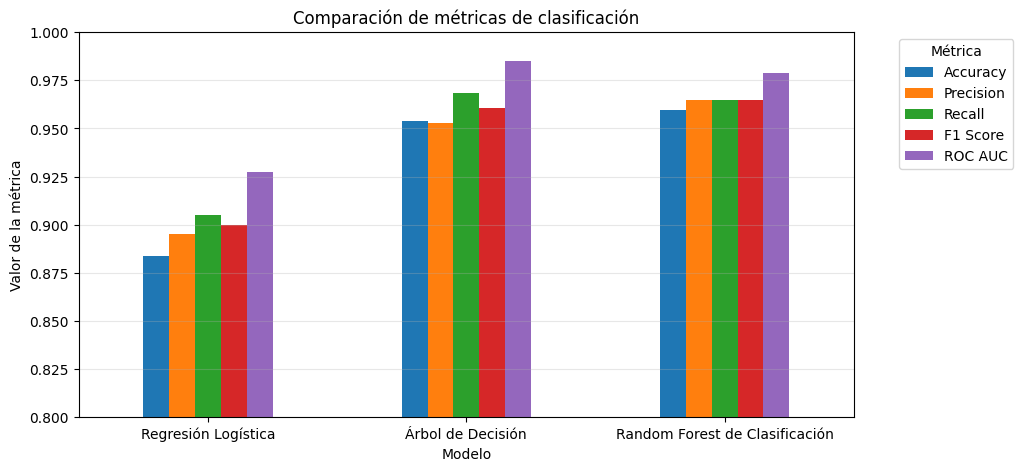

In [80]:
comparison_plot = comparison.set_index("Modelo")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de métricas de clasificación")
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

El gráfico permite comparar visualmente lo ya antes mencionado.

Se observa que la Regresión Logística obtiene los valores más bajos en todas las métricas. En cambio, el Árbol de Decisión y Random Forest presentan resultados considerablemente superiores.

Random Forest destaca por obtener la mayor Accuracy y valores muy equilibrados en Precision, Recall y F1-Score. Por otro lado, el Árbol de Decisión presenta un ROC AUC levemente superior, aunque la diferencia con Random Forest es mínima.

### 5.2.2 Análisis de las matrices de confusión de los Modelos de Clasificación

A diferencia de los modelos de regresión, en clasificación el residuo clásico `e = y_real − ŷ` pierde utilidad como herramienta de diagnóstico: como tanto el valor real como la predicción son etiquetas discretas (0 = CT, 1 = T), el residuo solo puede tomar tres valores:

- **e = 0**: predicción correcta (acierto).
- **e = +1**: el valor real es 1 (T gana) y el modelo predijo 0 → **Falso Negativo**.
- **e = −1**: el valor real es 0 (CT gana) y el modelo predijo 1 → **Falso Positivo**.

Un histograma de estos residuos solo repetiría el conteo de aciertos y errores, por lo que el equivalente del análisis de residuos en clasificación es el **análisis de errores**: estudiar cuántos errores comete cada modelo, de qué tipo son (FP vs FN) y si se concentran en alguna de las dos clases. La matriz de confusión es precisamente la herramienta que descompone estos "residuos": la diagonal contiene los aciertos (e = 0) y las celdas fuera de la diagonal los dos tipos de error. A continuación se comparan las matrices de confusión de los tres modelos lado a lado.

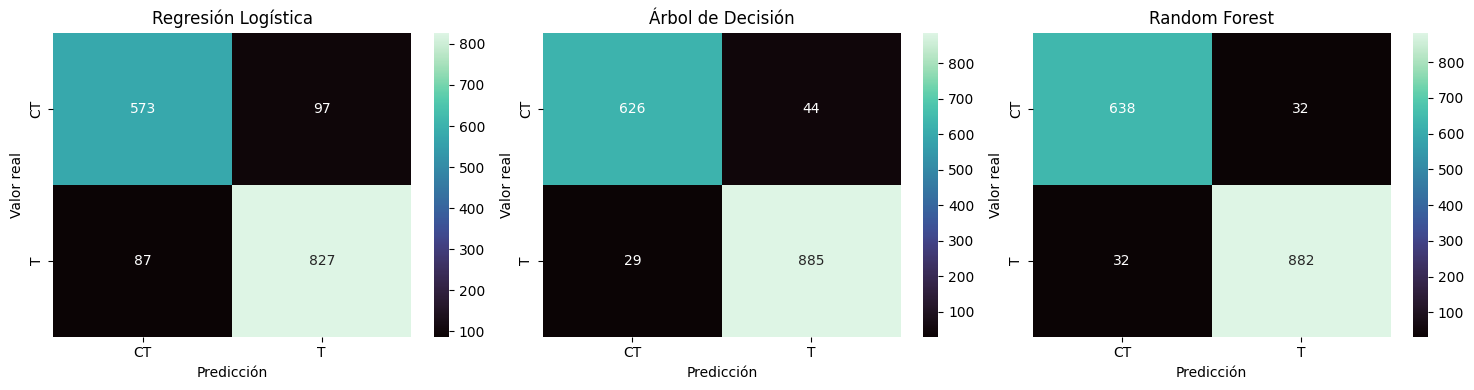

In [81]:
listado = {
    "Regresión Logística": cm_logistic,
    "Árbol de Decisión": cm_tree,
    "Random Forest": cm_random_forest
}

plt.figure(figsize=(15, 4))

for nombre, cm in listado.items():
    plt.subplot(1, 3, list(listado.keys()).index(nombre) + 1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="mako",
        xticklabels=["CT", "T"],
        yticklabels=["CT", "T"]
    )
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.title(nombre)
    plt.tight_layout()

plt.show()

La comparación lado a lado permite cuantificar y localizar los errores de cada modelo:

**Regresión Logística** — 184 errores (11.6% del conjunto de prueba)
Clasificó correctamente 573 rondas de CT y 827 de T. Cometió 97 falsos positivos (rondas de CT predichas como T) y 87 falsos negativos (rondas de T predichas como CT). El error está repartido de forma relativamente equilibrada entre ambas clases (97 vs 87), pero su volumen casi triplica el de los otros dos modelos.

**Árbol de Decisión** — 73 errores (4.6%)
Acertó 626 rondas de CT y 885 de T. Sus errores están sesgados hacia los falsos positivos: 44 FP contra 29 FN. En términos de tasa de error por clase, se equivoca en el 6.6% de las rondas reales de CT frente a solo el 3.2% de las de T; es decir, le cuesta más reconocer las victorias de CounterTerrorist, lo que es coherente con su Recall de CT (93%) observado en la Fase 4.

**Random Forest** — 64 errores (4.0%)
Acertó 638 rondas de CT y 882 de T, con el error perfectamente simétrico: 32 FP y 32 FN. Además de ser el modelo con menos errores totales, es el único que no presenta sesgo hacia ninguna clase (4.8% de error en rondas de CT y 3.5% en rondas de T).

El Random Forest presenta, por lo tanto, el comportamiento de errores más favorable de los tres modelos evaluados.

---
## Conclusión Fase 5

A partir de los resultados obtenidos durante la fase de modelamiento, fue posible comparar distintos enfoques para la predicción del ganador de una ronda de Counter-Strike: Global Offensive.

En una primera etapa se evaluaron modelos de regresión, específicamente Regresión Lineal, Support Vector Regression (SVR) y Árbol de Decisión de Regresión. Si bien estos modelos lograron capturar parte del comportamiento de los datos, se concluyó que no eran los más adecuados para el problema planteado, ya que la variable objetivo (`RoundWinner`) corresponde a una variable binaria y, por lo tanto, el problema debía abordarse como una tarea de clasificación.

Posteriormente se evaluaron tres modelos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest. Para cada uno de ellos se analizaron métricas de desempeño como Accuracy, Precision, Recall, F1-Score y ROC AUC, además de sus respectivas matrices de confusión.

Considerando el conjunto de métricas analizadas, Random Forest fue seleccionado como el modelo final del proyecto, ya que presentó el comportamiento más robusto y consistente para la predicción del ganador de una ronda. Su capacidad para combinar múltiples árboles de decisión permitió mejorar la generalización del modelo y reducir los errores de clasificación respecto a los demás algoritmos evaluados.

En consecuencia, se concluye que los modelos de clasificación, y particularmente Random Forest, constituyen la alternativa más adecuada para resolver el problema planteado en este trabajo, logrando predecir el ganador de una ronda de Counter-Strike: Global Offensive con un alto nivel de precisión y capacidad de discriminación.


## Fase 6: Deployment

In [82]:
# Ir al github
# https://github.com/paufriasest/Informe_Tecnico_CS-GO

## Fase 7: What if...?

En esta fase quisimos analizar que resultados hubieramos obtenido con los modelos de regresión de haber seguido el objetivo con una variable continua.
De esta manera hemos seleccionado el siguiente objetivo:  
"A partir de las estadisticas que contiene una ronda de CS:GO (economía, armamento, granadas, distancia, etc...) se puede predecir el tiempo promedio que los jugadores permanecen con vida durante una ronda (`AvgTimeAlive`)".

Empezaremos haciendo una copia del dataset resultante de Corrección Data Preparation, aqui seleccionaremos las variables predictorias y objetiva, posteriormente separaremos el dataset en los datos de validacion y entrenamiento (ocuparemos la misma proporción que antes).  
Nota: Es necesario clipear el AvgTimeAlive ya que se entenderá que hay un maximo teorico que definimos con anterioridad.

In [83]:
df_regression = df_model.copy()

target_regression = "AvgTimeAlive"

df_regression["AvgTimeAlive"] = df_regression["AvgTimeAlive"].clip(
    lower=15,
    upper=155
)

X_regression = df_regression.drop(
    columns=[
        target_regression,
        target #el ropundwinner
    ]
)

y_regression = df_regression[target_regression]


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=67
)

Ahora evaluaremos con lis mismos modelos que definimos en la Fase 4.
- Regresión Lineal Múltiple
- Árboles de desición para Regresión
- SVR - Support Vector Regression

#### Regresión Lineal Múltiple

In [84]:
linear_model_rg = LinearRegression()
linear_model_rg.fit(X_train_reg, y_train_reg)

y_pred_lr_rg = linear_model_rg.predict(X_test_reg)

mae_lr_rg = mean_absolute_error(y_test_reg, y_pred_lr_rg)
mse_lr_rg = mean_squared_error(y_test_reg, y_pred_lr_rg)
r2_lr_rg = r2_score(y_test_reg, y_pred_lr_rg)

print(f"Desempeño Modelo de Regresión Lineal Múltiple")
print(f"MAE: {mae_lr_rg:.4f}")
print(f"MSE: {mse_lr_rg:.4f}")
print(f"R2: {r2_lr_rg:.4f}")

Desempeño Modelo de Regresión Lineal Múltiple
MAE: 13.8142
MSE: 329.4825
R2: 0.4009


La Regresión Lineal Múltiple, obtuvo un MAE de 13.8142, indicando que sus predicciones se alejan, en promedio, aproximadamente 13.8 segundos del tiempo promedio real de supervivencia. El MSE alcanzó un valor de 329.4825.

Por otra parte, el R² fue de 0.40, lo que indica que el modelo explica solamente un 40% de la variabilidad observada en AvgTimeAlive. En conclusión, bastante mediocre el resultado con este modelo.

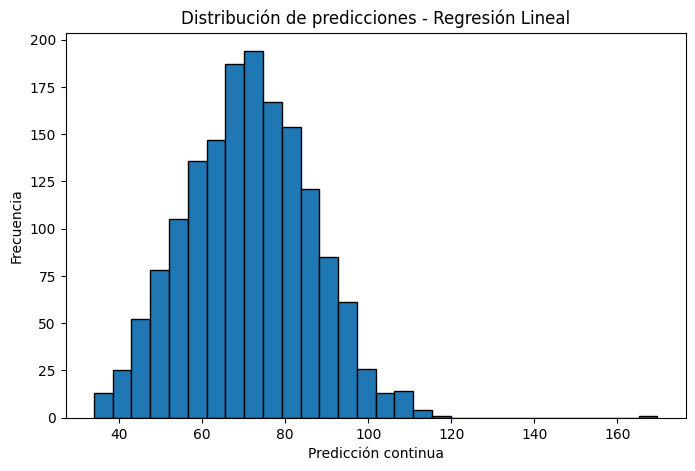

In [85]:
plt.figure(figsize=(8, 5))

plt.hist(y_pred_lr_rg, bins=30, edgecolor="black")

plt.xlabel("Predicción continua")
plt.ylabel("Frecuencia")
plt.title("Distribución de predicciones - Regresión Lineal")
plt.show()

El histograma muestra que la mayoría de las predicciones se concentra entre aproximadamente 50 y 95 segundos. Se observa de igual forma valores superiores a los definidos pero esto por que el modelo no impone limites a los rangos.

#### Árboles de desición para Regresión

In [86]:
tree_reg_rg = DecisionTreeRegressor(
    random_state=67,
    max_depth=4
)

tree_reg_rg.fit(X_train_reg, y_train_reg)

y_pred_tree_rg = tree_reg_rg.predict(X_test_reg)

mae_tree_rg = mean_absolute_error(y_test_reg, y_pred_tree_rg)
mse_tree_rg = mean_squared_error(y_test_reg, y_pred_tree_rg)
r2_tree_rg = r2_score(y_test_reg, y_pred_tree_rg)

print(f"Desempeño Modelo de Árboles de desición para Regresión")
print(f"MAE: {mae_tree_rg:.4f}")
print(f"MSE: {mse_tree_rg:.4f}")
print(f"R2: {r2_tree_rg:.4f}")

Desempeño Modelo de Árboles de desición para Regresión
MAE: 11.8623
MSE: 259.6756
R2: 0.5278


El Árboles de desición para Regresión, obtuvo un MAE de 11.8623, indicando que sus predicciones se alejan, en promedio, aproximadamente 11.8 segundos del tiempo promedio real de supervivencia, 2s menos que el anterior modelo. El MSE alcanzó un valor de 259.6756, disminuye el error en comparacion tambien con regresion lineal.

Por otra parte, el R² fue de 0.5278, lo que indica que el modelo explica solamente un 52% de la variabilidad observada en AvgTimeAlive. En conclusión, mejoró en comparacion con modelos de regresion, es posible que la variable AvgTimeAlive no se exprese en forma de recta.

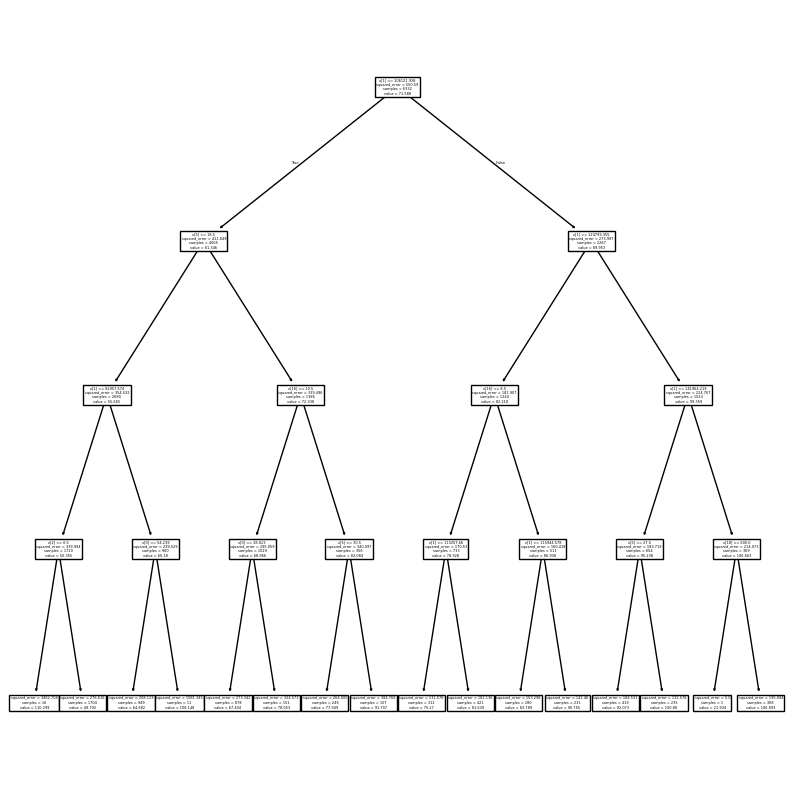

In [87]:
plt.subplots(1,1,figsize=(10,10))
tree_graph = tree.plot_tree(tree_reg_rg)

#### Support Vector Regression

In [88]:
scaler = StandardScaler()

X_train_scaler_rg = scaler.fit_transform(X_train_reg)
X_test_scaler_rg = scaler.transform(X_test_reg)

svr_model_rg = sklearn.svm.SVR(kernel="rbf")

svr_model_rg.fit(X_train_scaler_rg, y_train_reg)

y_pred_svr_rg = svr_model_rg.predict(X_test_scaler_rg)

mae_svr_rg = mean_absolute_error(y_test_reg, y_pred_svr_rg)
mse_svr_rg = mean_squared_error(y_test_reg, y_pred_svr_rg)
r2_svr_rg = r2_score(y_test_reg, y_pred_svr_rg)

print(f"Desempeño Modelo de Support Vector Regression")
print(f"MAE: {mae_svr_rg:.4f}")
print(f"MSE: {mse_svr_rg:.4f}")
print(f"R2: {r2_svr_rg:.4f}")

Desempeño Modelo de Support Vector Regression
MAE: 13.4410
MSE: 323.5436
R2: 0.4117


Support Vector Regression, obtuvo un MAE de 13.4410, indicando un error promedio aproximado de 13.4 segundos en la estimación de `AvgTimeAlive`. El MSE alcanzó un valor de 323.5436, mientras que el R² fue de un 41%.

Los resultados obtenidos son bastante similares a los de Regresión Lineal Múltiple, mi hipotesis es que no estan ajustados los hiperparametros correctamente, por lo mismo internet recomendo hacer un grid search para encontrar la mejor combinacion de estos y volver a evaluar con las metricas utilziadas.


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C": [1, 10, 50, 100],
    "svr__gamma": ["scale", 0.01, 0.05, 0.1],
    "svr__epsilon": [0.1, 1, 3, 5]
}

grid_svr = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_svr.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:", grid_svr.best_params_)
print("Mejor R² validación:", grid_svr.best_score_)

y_pred_svr_tuned = grid_svr.predict(X_test_reg)

Mejores parámetros: {'svr__C': 100, 'svr__epsilon': 5, 'svr__gamma': 0.01}
Mejor R² validación: 0.573529159424875


In [90]:
mae_svr_tuned = mean_absolute_error(y_test_reg, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test_reg, y_pred_svr_tuned)
r2_svr_tuned = r2_score(y_test_reg, y_pred_svr_tuned)

print(f"MAE: {mae_svr_tuned:.4f}")
print(f"MSE: {mse_svr_tuned:.4f}")
print(f"R²: {r2_svr_tuned:.4f}")

MAE: 11.0256
MSE: 248.8008
R²: 0.5476


Luego de esta atrocidad que demora 15 minutos en ejecutarse, en efecto habia que ocupar hiperparametros para mejores resultados, para el MAE se obtuvo 11.0256, el MSE fue de 248.8008 y el R² fue de 0.5476.

Esto significa que el modelo presenta un error promedio cercano a 11 segundos y logra explicar aproximadamente el 54.76% de la variabilidad observada en `AvgTimeAlive`.

El resultado obtenido ahora es mejor que el SVR sin optimziarm, que la regrersión lineal e incluso el Decision Tree Regressor. Por lo tanto, el SVR optimizado se posiciona como el modelo con mejor desempeño dentro del escenario alternativo de regresión.

Además, el R² obtenido mediante validación cruzada fue de 0.5735, valor cercano al 0.5476 alcanzado en el conjunto de prueba. Esta proximidad sugiere que el modelo mantiene una capacidad de generalización relativamente estable.


---
## Conclusión ultima fase
Podemos concluir que para evaluar modelos de regresión no solo basta considerar que modelos ocupar y que la variable sea continua si no también entender los datos que estamos ocupando. Al principio se hizo el calculo de las metricas para Regresión Lineal Multiple y nos percatamos que tenia unos valores atipicos lo que fue necesario clipear la columna para obtener datos más cercanos a un comportamiento esperado dentro del CS:GO.
También fue necesario de ocupar correctamente el modelo, es decir, aplicar los hiperparametros para obtener mejores resultados para evaluar. Sin estas consideraciones los calculos hubieran sido distintos.

### Los PIPSHlines

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import joblib

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svr",
        SVR(
            kernel="rbf",
            C=100,
            gamma=0.01,
            epsilon=5
        )
    )
])

svr_pipeline.fit(X_train_reg, y_train_reg)

regression_artifact = {
    "model": svr_pipeline,
    "features": X_train_reg.columns.tolist(),
    "target": "AvgTimeAlive",
    "minimum_prediction": 15,
    "maximum_prediction": 155
}

joblib.dump(
    regression_artifact,
    "../model/model_train_svr_regressor.joblib"
)

['../model/model_train_svr_regressor.joblib']

In [93]:
classification_artifact = {
    "model": random_forest_classifier,
    "features": X_train.columns.tolist(),
    "target": "RoundWinner",
    "class_names": {
        0: "CounterTerrorist",
        1: "Terrorist"
    }
}

joblib.dump(
    classification_artifact,
    "../model/model_train_randomforest_classifier.joblib"
)

['../model/model_train_randomforest_classifier.joblib']